In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
tilt = pd.read_csv("tilt-angle.csv")

In [3]:
tilt_neutral = tilt['neutral']
tilt_neutral_ca = tilt['Neutral-Ca']

tilt_two = tilt['+2-state']
tilt_two_ca = tilt['+2-Ca']

tilt_four = tilt['+4-state']
tilt_four_ca = tilt['+4-Ca']

tilt_five = tilt['+5-state']
tilt_five_ca = tilt['+5-Ca']

In [4]:
df_neutral = pd.DataFrame({'Tilt_Angle': tilt_neutral.values}, index=tilt_neutral.index)
df_neutral.index.name = 'Timeframes'

df_neutral_ca = pd.DataFrame({'Tilt_Angle': tilt_neutral_ca.values}, index=tilt_neutral_ca.index)
df_neutral_ca.index.name = 'Timeframes'


df_two = pd.DataFrame({'Tilt_Angle': tilt_two.values}, index=tilt_two.index)
df_two.index.name = 'Timeframes'

df_two_ca = pd.DataFrame({'Tilt_Angle': tilt_two_ca.values}, index=tilt_two_ca.index)
df_two_ca.index.name = 'Timeframes'


df_four = pd.DataFrame({'Tilt_Angle': tilt_four.values}, index=tilt_four.index)
df_four.index.name = 'Timeframes'

df_four_ca = pd.DataFrame({'Tilt_Angle': tilt_four_ca.values}, index=tilt_four_ca.index)
df_four_ca.index.name = 'Timeframes'

df_five = pd.DataFrame({'Tilt_Angle': tilt_five.values}, index=tilt_five.index)
df_five.index.name = 'Timeframes'

df_five_ca = pd.DataFrame({'Tilt_Angle': tilt_five_ca.values}, index=tilt_five_ca.index)
df_five_ca.index.name = 'Timeframes'

In [5]:
print(df_neutral)

            Tilt_Angle
Timeframes            
0              5.93670
1              7.14622
2             10.63990
3              9.89481
4              7.68587
...                ...
4996           3.56057
4997           2.93498
4998           1.82070
4999           5.18637
5000           4.30584

[5001 rows x 1 columns]


In [6]:
def plot_tilt(df1, df2, save_name):
    fig, ax = plt.subplots(figsize=(10, 7), dpi=300)
    
    plt.plot(df1.index[:5000]/10, df1['Tilt_Angle'][:5000],color="blue",alpha=0.15)
    rolling_avg_df1 = df1['Tilt_Angle'].rolling(window=50).mean()
    plt.plot(df1.index[:5000]/10, rolling_avg_df1[:5000], color="blue", label=r"without Ca$^{2+}$")
    
    plt.plot(df2.index[:5000]/10, df2['Tilt_Angle'][:5000], color="red", alpha=0.15)
    
    rolling_avg_df2 = df2['Tilt_Angle'].rolling(window=50).mean()
    plt.plot(df2.index[:5000]/10, rolling_avg_df2[:5000], color="red", label=r"with Ca$^{2+}$")

    ax.set_xlabel("Time (ns)", fontsize=22)
    plt.xticks(fontsize=20)
    ax.set_ylabel("Tilt Angle (degree)", fontsize=22)
    plt.yticks(fontsize=20)
    plt.tight_layout()
    #plt.legend(fontsize=20)
    plt.savefig(save_name, dpi=300)
    plt.show()

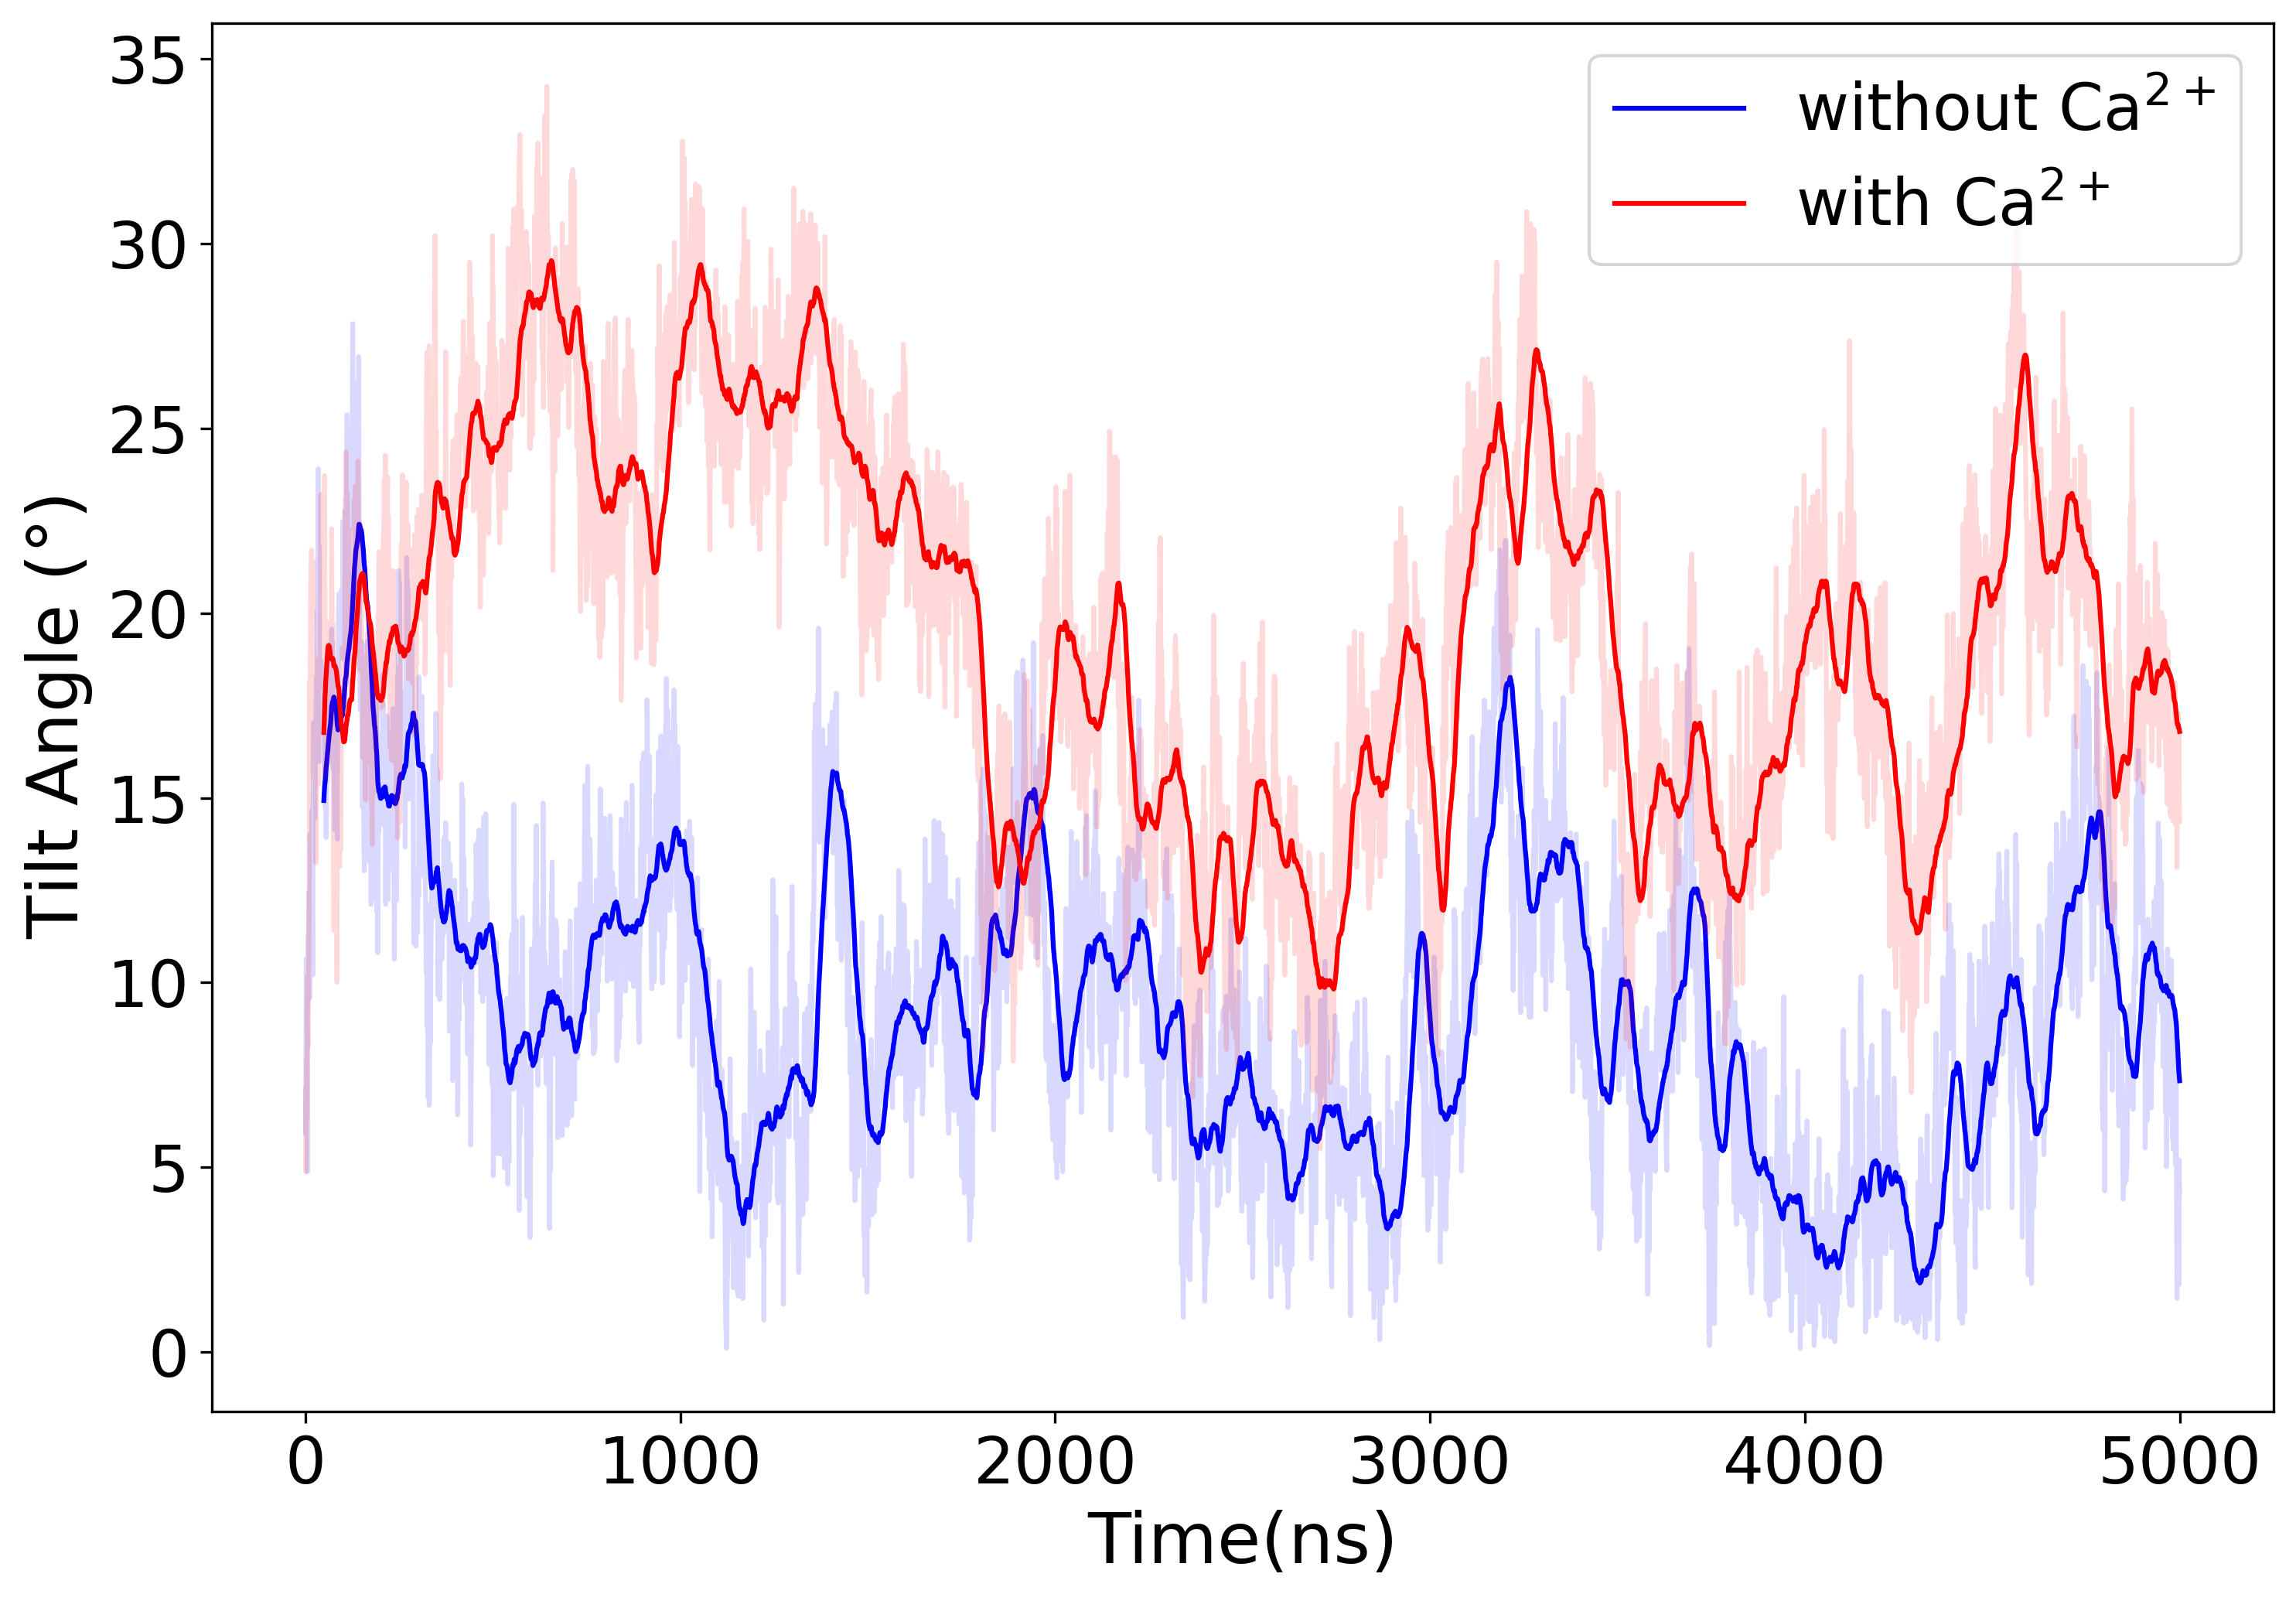

In [42]:
#plt.plot(df_neutral['Timeframe'],df_neutral['Water molecules'])
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
plt.plot(df_neutral.index,df_neutral['Tilt_Angle'],color="blue",alpha=0.15)
rolling_avg = df_neutral['Tilt_Angle'].rolling(window=50).mean()
plt.plot(df_neutral.index,rolling_avg,color="blue",label = r"without Ca$^{2+}$")

plt.plot(df_neutral_ca.index,df_neutral_ca['Tilt_Angle'],color="red",alpha=0.15)
rolling_avg = df_neutral_ca['Tilt_Angle'].rolling(window=50).mean()
plt.plot(df_neutral_ca.index,rolling_avg,color="red",label = r"with Ca$^{2+}$")

ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Tilt Angle ($\degree$)", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.legend(fontsize=20)
#plt.savefig("Number of water molecules (Neutral-state) with Ca 500ns with 3A (rolling).pdf",dpi=300)
#plt.savefig("Number of water molecules with and without Ca (rolling).png",dpi=300)
plt.show()

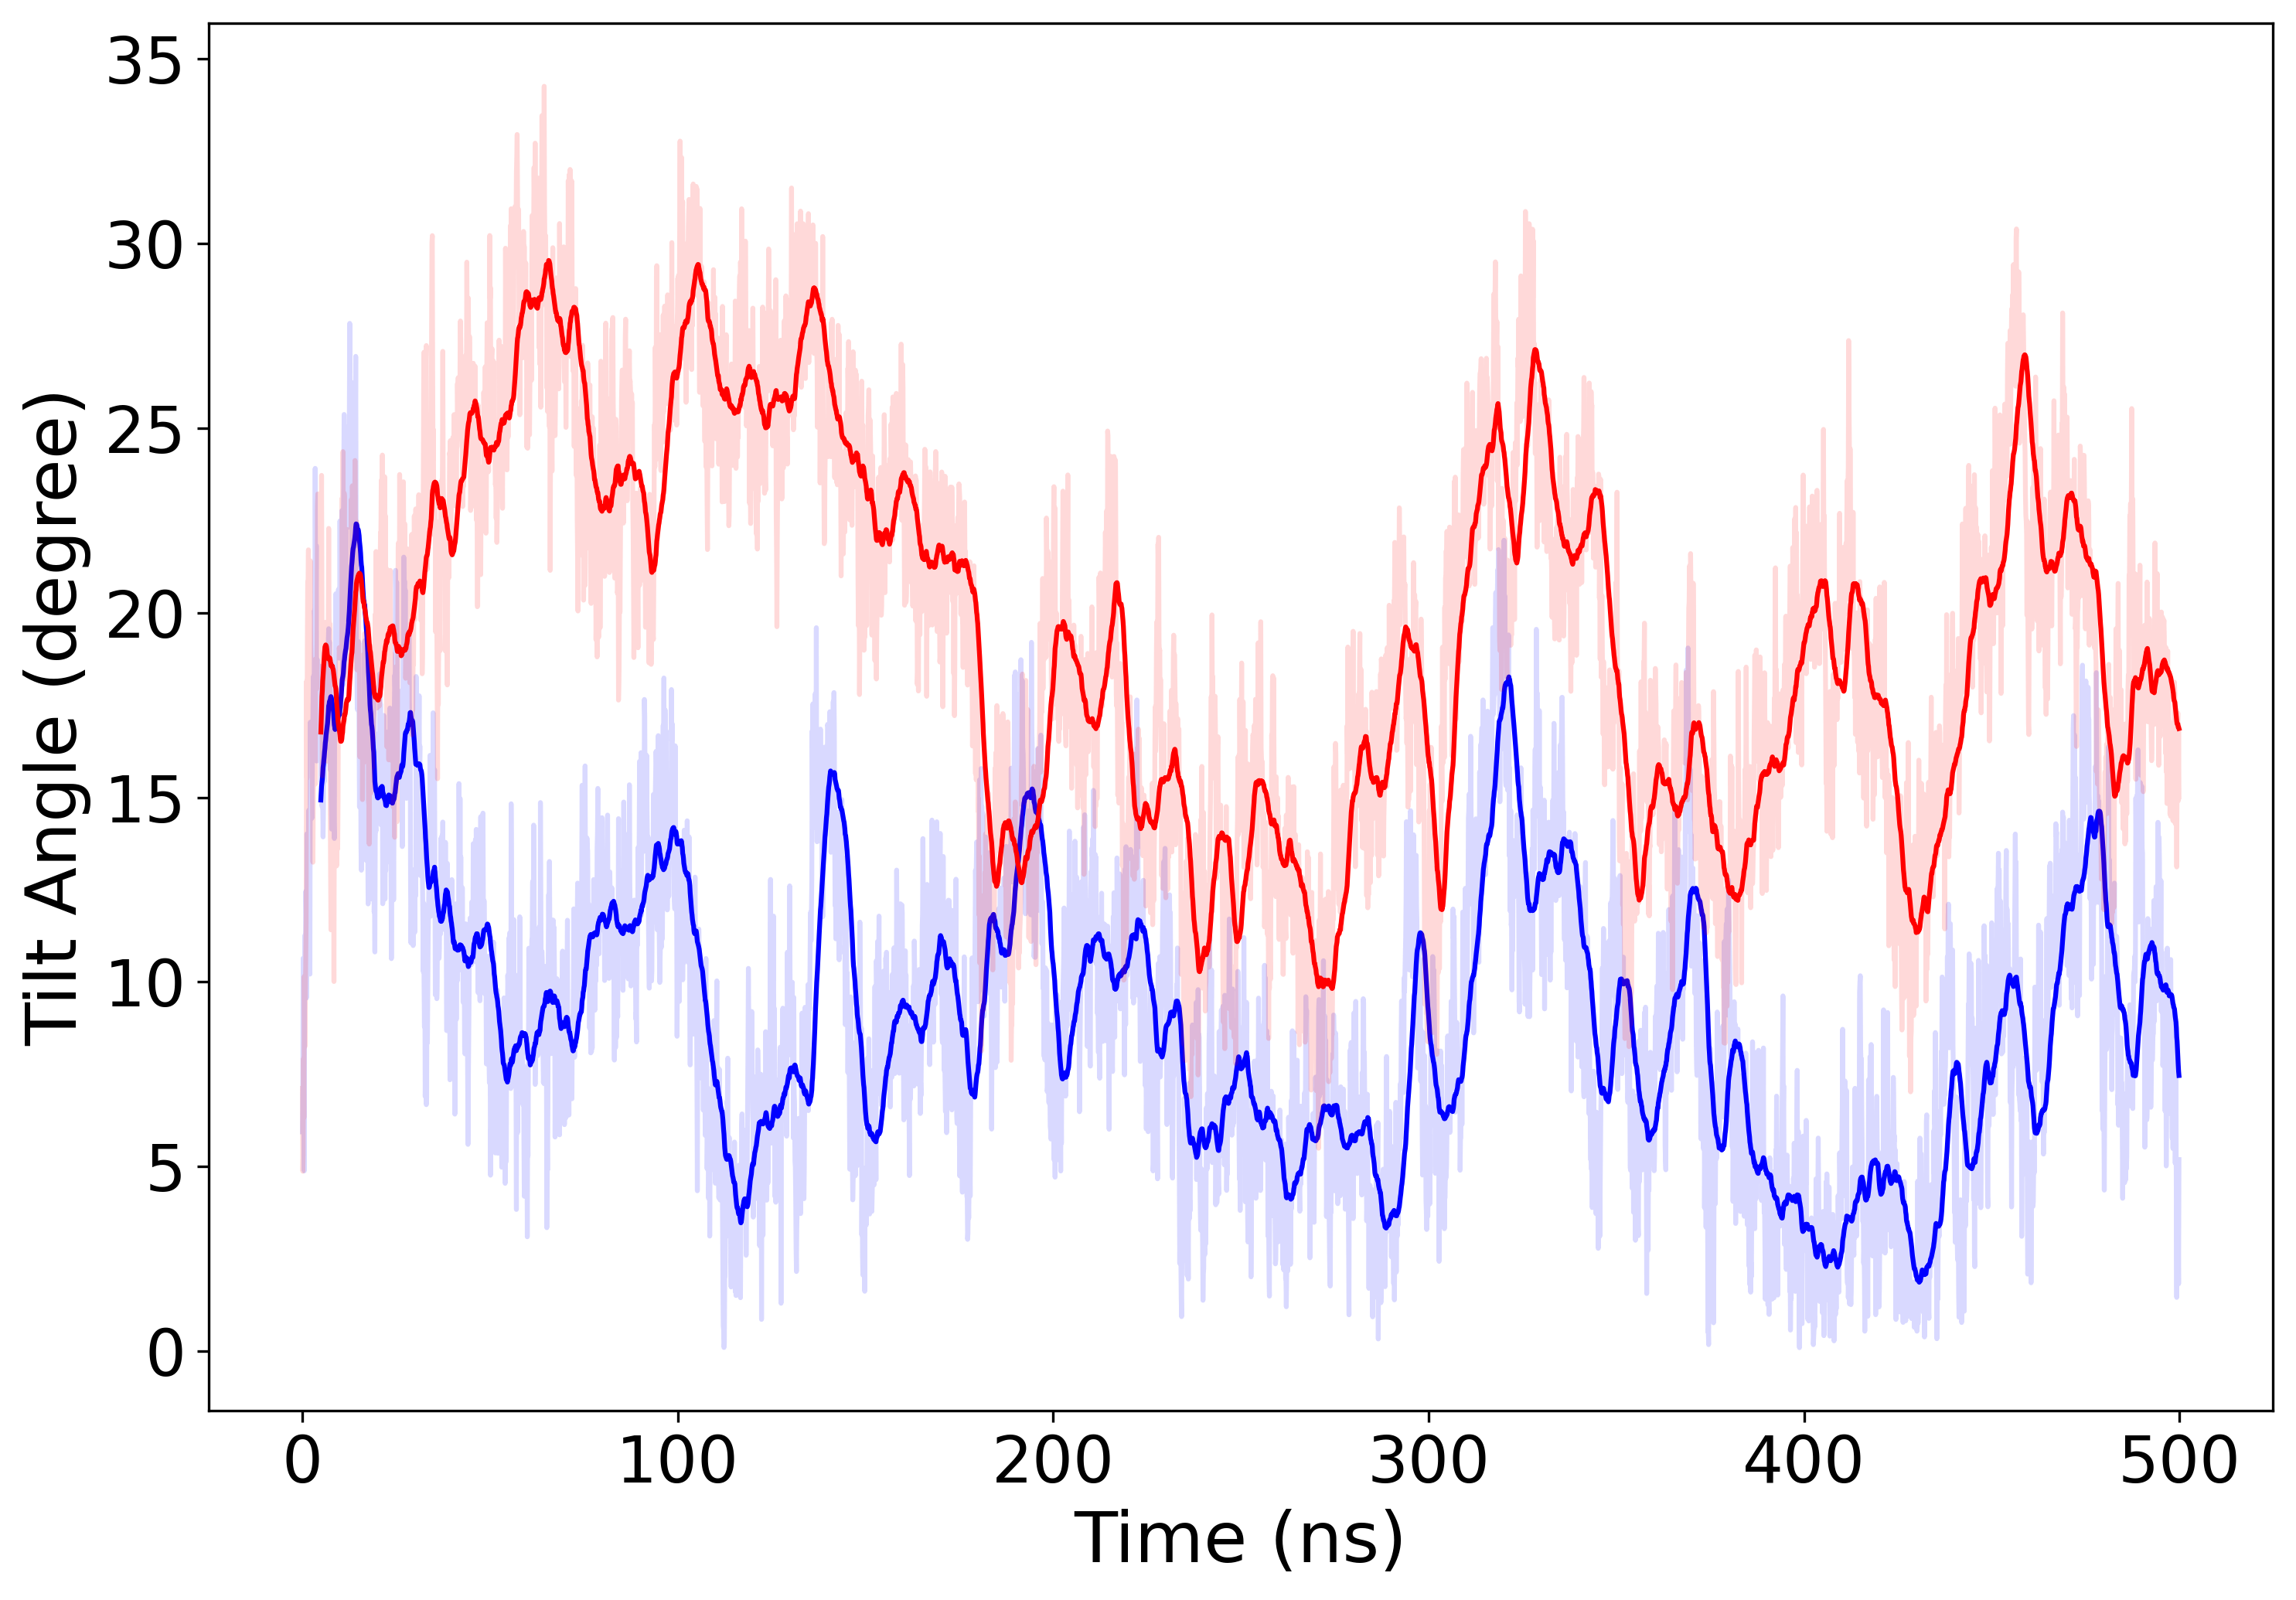

In [7]:
plot_tilt(df_neutral,df_neutral_ca,"Tilt_neutral.png")

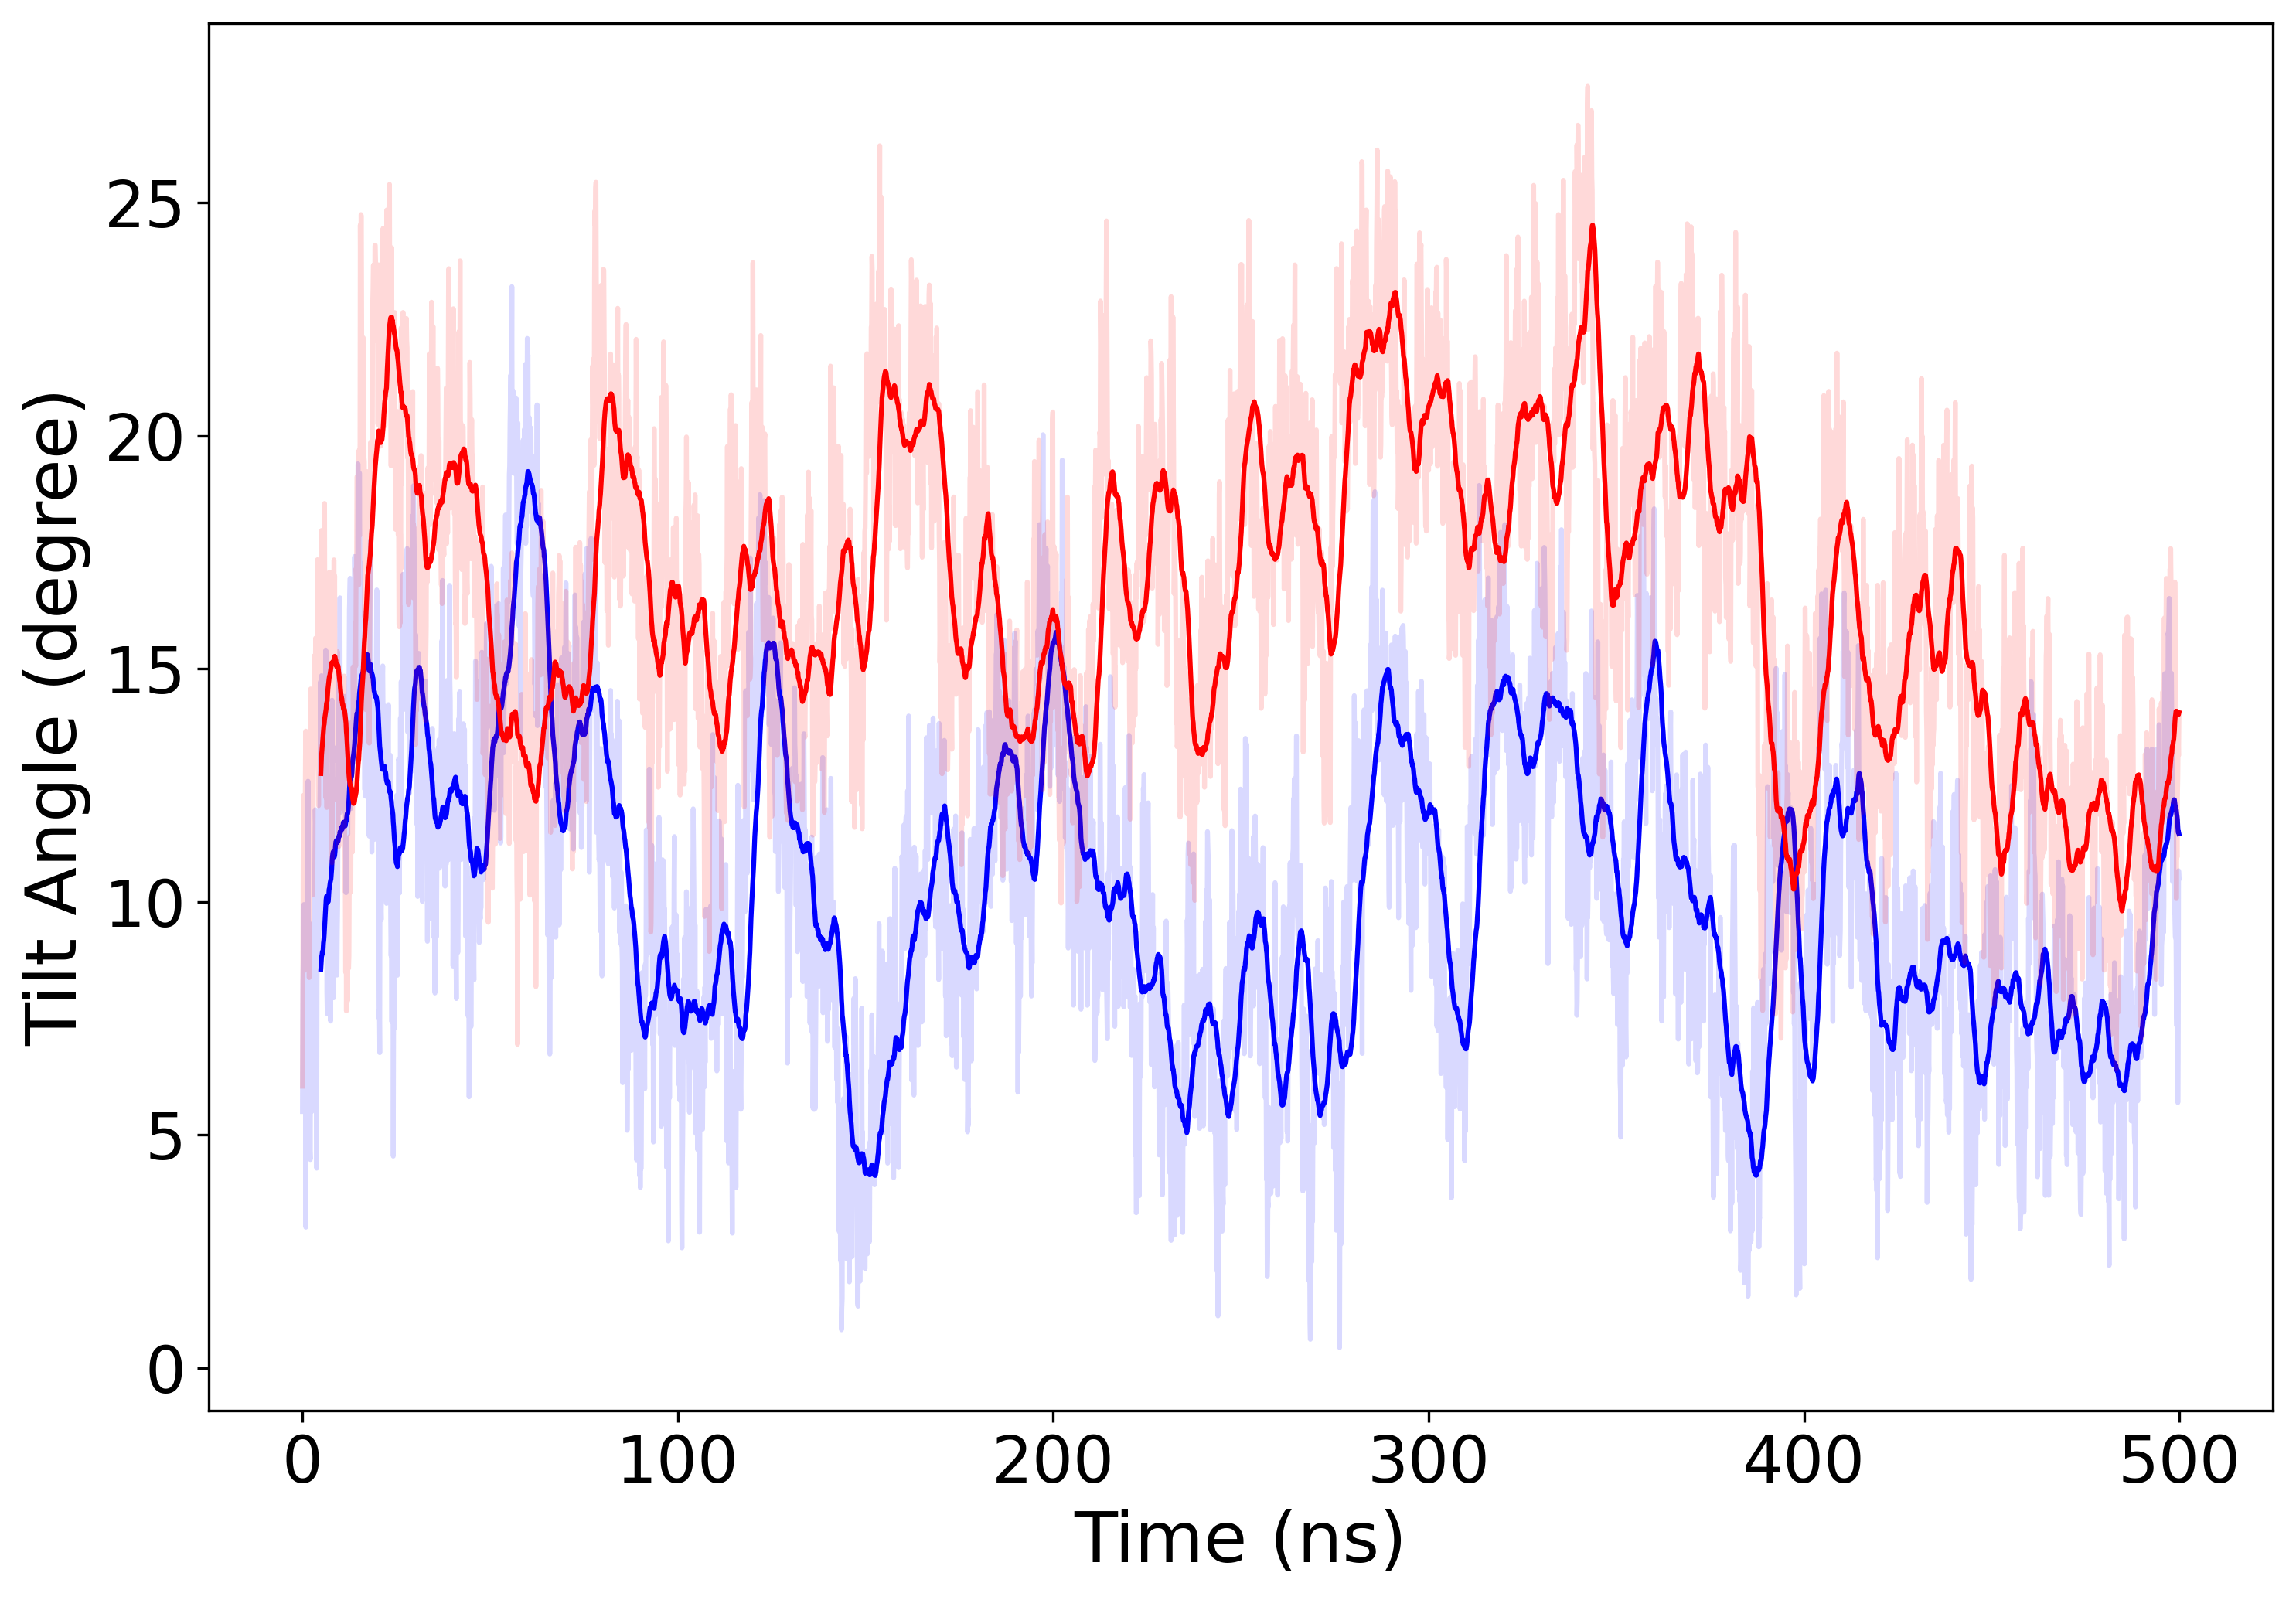

In [8]:
plot_tilt(df_two,df_two_ca,"Tilt_two.png")

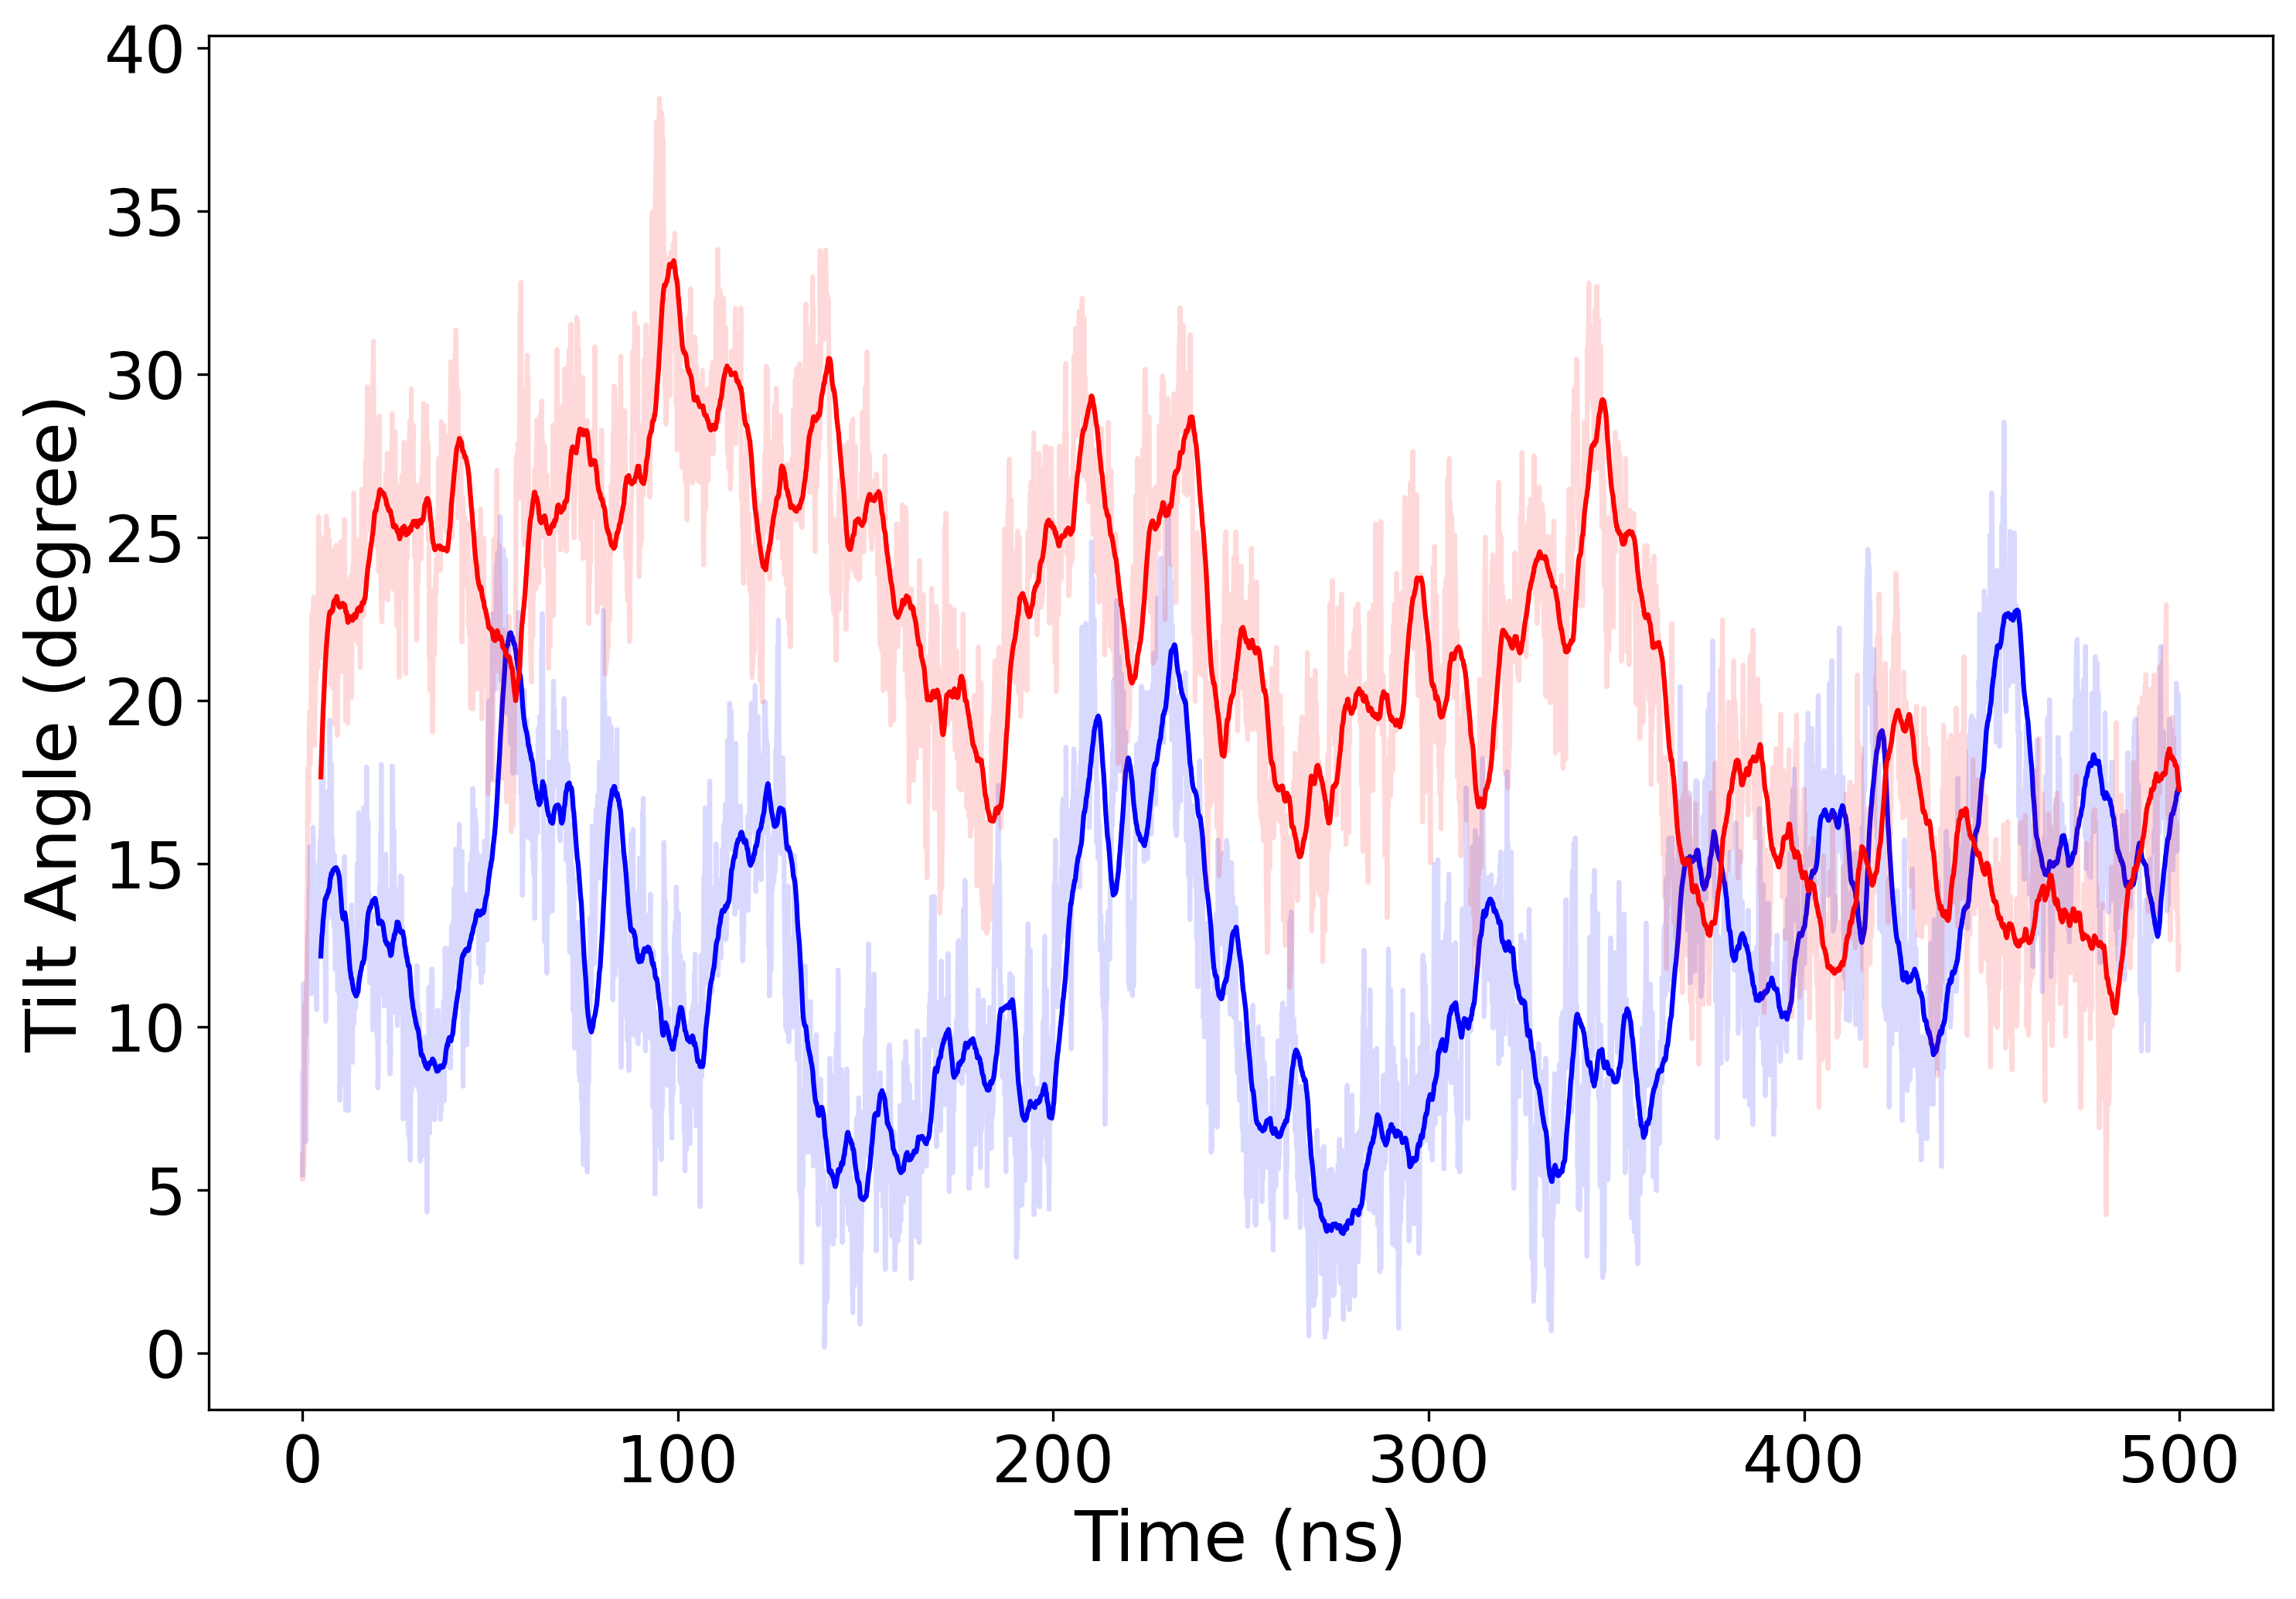

In [9]:
plot_tilt(df_four,df_four_ca,"Tilt_four.png")

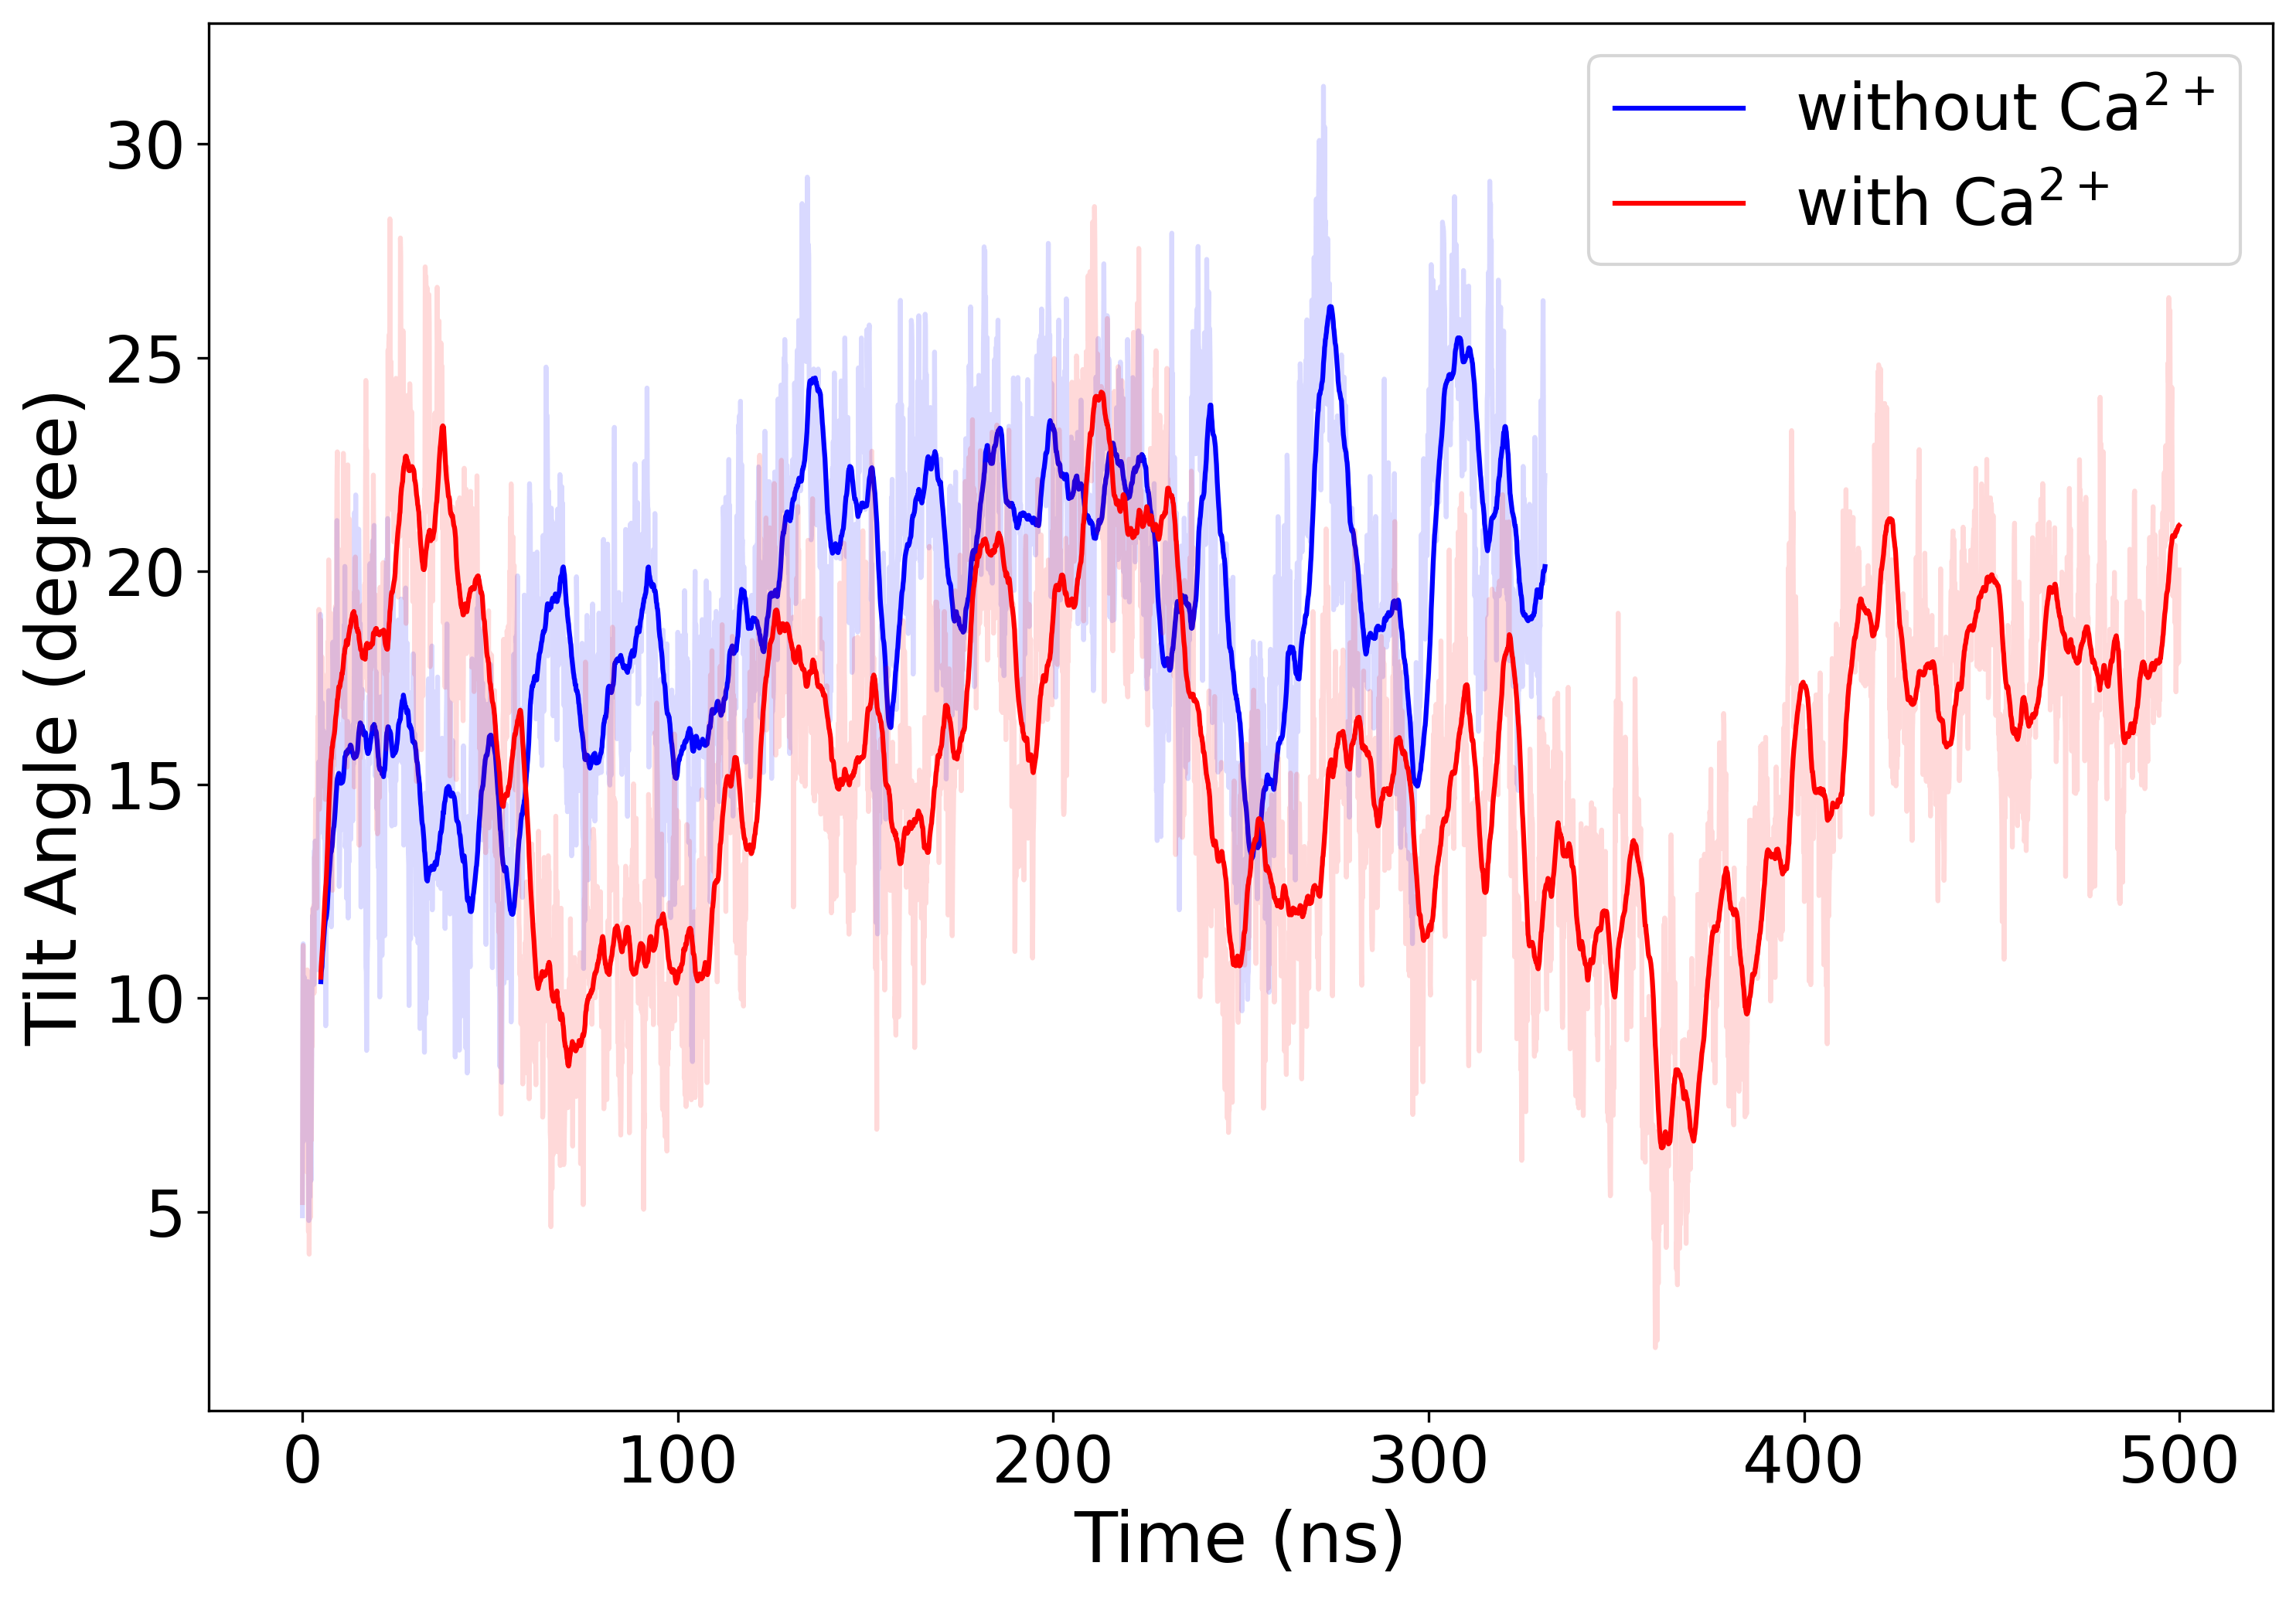

In [58]:
plot_tilt(df_five,df_five_ca,"Tilt_five.pdf")

In [61]:
import numpy as np
import MDAnalysis as mda

u = mda.Universe("../+5-with-Ca.gro","")

selection_1 = "(resid 5:8) and name CA"
selection_2 = "(resid 26:29) and name CA"

with open("tilt_five_ca.csv", "w") as f:
    f.write("Timestep\tAngle (degrees)\n")
    
    for ts in u.trajectory:
        COM_1 = u.select_atoms(selection_1).center_of_mass()
        COM_2 = u.select_atoms(selection_2).center_of_mass()
        vector = COM_2 - COM_1
        z_axis = np.array([0, 0, 1]) 
        angle = np.arccos(np.dot(vector, z_axis) / (np.linalg.norm(vector) * np.linalg.norm(z_axis)))
        angle_deg = np.degrees(angle)

        f.write(f"{ts.frame}\t{angle_deg}\n")

In [65]:
df_five = pd.read_csv("tilt_five.csv")
print(df_five['Timestep\tAngle (degrees)'])

0           0\t4.904179326564228
1          1\t11.194659030479077
2          2\t11.270989020599876
3           3\t6.647613801477632
4           4\t7.487131553784808
                  ...           
5165     5165\t23.97420761490535
5166      5166\t20.7963955503139
5167    5167\t21.155062438148203
5168     5168\t23.63636543929308
5169    5169\t24.076072796811847
Name: Timestep\tAngle (degrees), Length: 5170, dtype: object


In [70]:
import numpy as np
import pandas as pd
import MDAnalysis as mda

u = mda.Universe("../+5-without-calcium.gro", "../+5-without-calcium.xtc")
selection_1 = "(resid 5:8) and name CA"
selection_2 = "(resid 26:29) and name CA"
timesteps = []
angles_deg = []

for ts in u.trajectory:
    COM_1 = u.select_atoms(selection_1).center_of_mass()
    COM_2 = u.select_atoms(selection_2).center_of_mass()

    vector = COM_2 - COM_1
    z_axis = np.array([0, 0, 1])
    angle = np.arccos(np.dot(vector, z_axis) / (np.linalg.norm(vector) * np.linalg.norm(z_axis)))
    angle_deg = np.degrees(angle)

    timesteps.append(ts.frame)
    angles_deg.append(angle_deg)

df = pd.DataFrame({'Tilt_Angle': angles_deg}, index=timesteps)
df.index.name = 'Timeframes'

In [71]:
print(df)

            Tilt_Angle
Timeframes            
0             4.904179
1            11.194659
2            11.270989
3             6.647614
4             7.487132
...                ...
5165         23.974208
5166         20.796396
5167         21.155062
5168         23.636365
5169         24.076073

[5170 rows x 1 columns]


In [72]:
df.to_csv('tilt_five.csv')

In [10]:
df_five = pd.read_csv("tilt_five.csv")
df_five_ca = pd.read_csv("tilt_five_ca.csv")

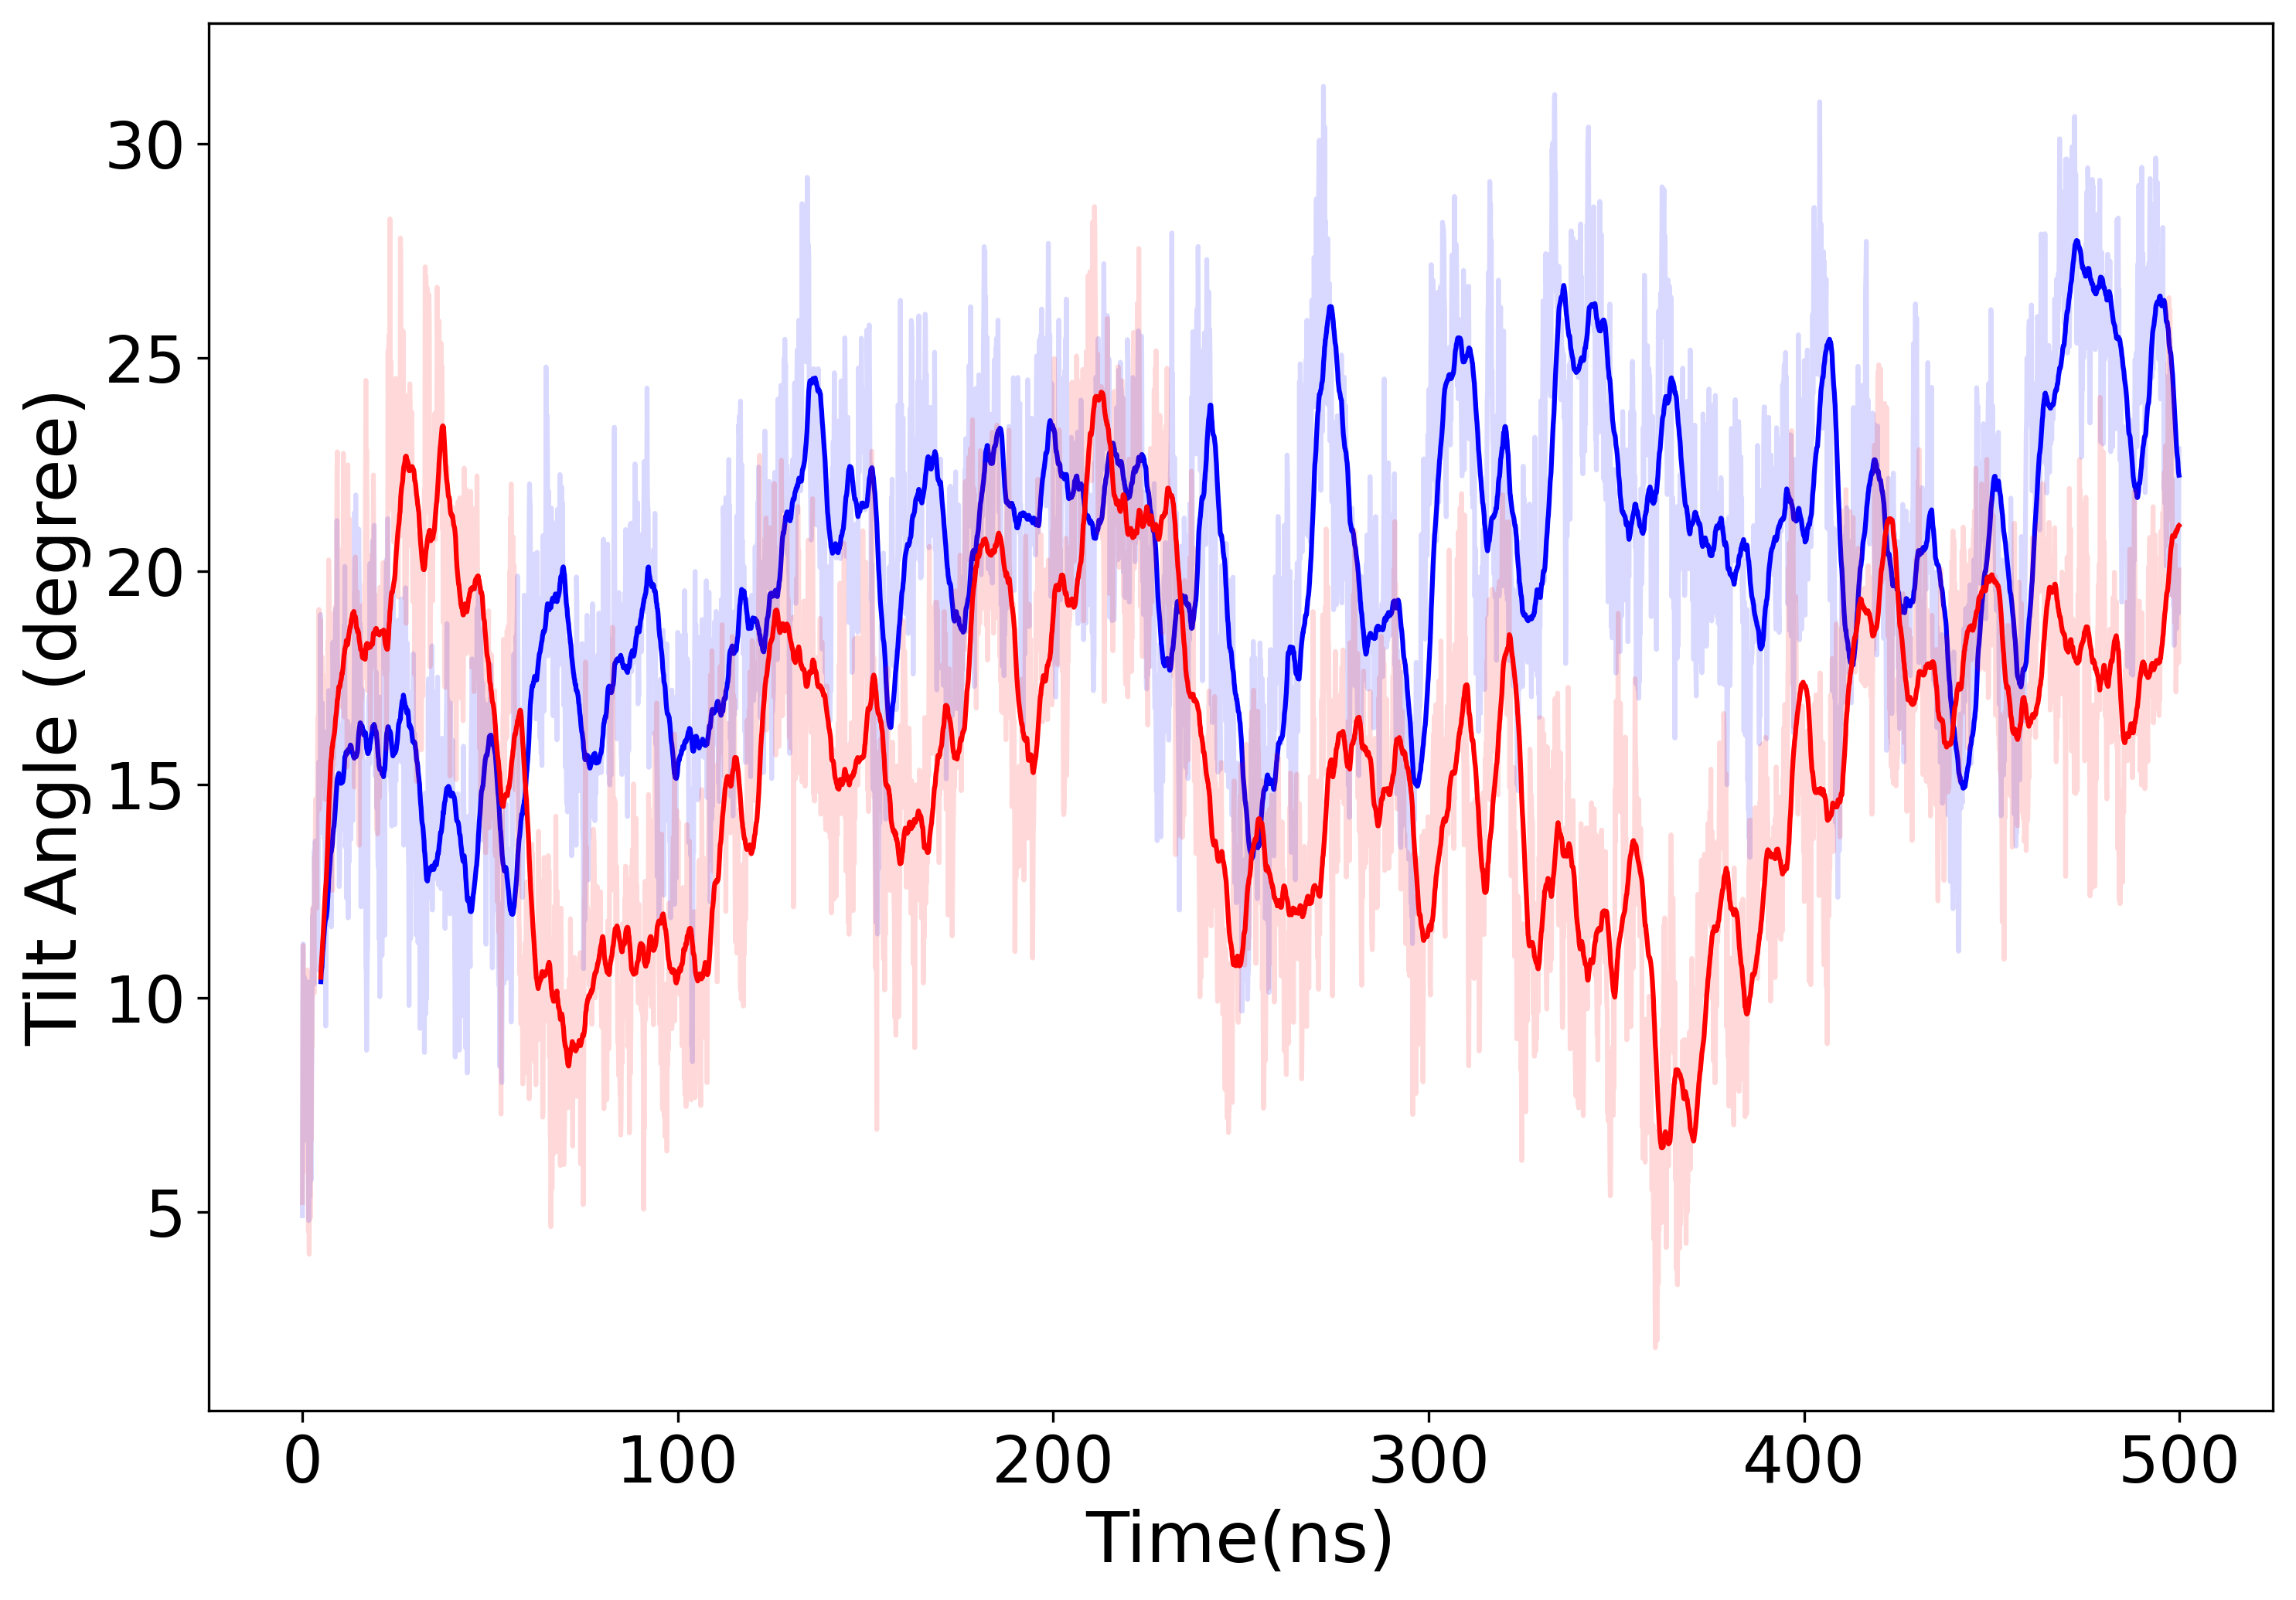

In [11]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300)
#plt.plot(df_neutral.index,df_neutral['Tilt_Angle'],color="blue",alpha=0.15)
plt.plot(df_five['Timeframes'][:5000]/10,df_five['Tilt_Angle'][:5000],color="blue",alpha=0.15)
rolling_avg = df_five['Tilt_Angle'][:5000].rolling(window=50).mean()
plt.plot(df_five['Timeframes'][:5000]/10,rolling_avg,color="blue",label = r"without Ca$^{2+}$")

plt.plot(df_five_ca['Timeframes'][:5000]/10,df_five_ca['Tilt_Angle'][:5000],color="red",alpha=0.15)
rolling_avg = df_five_ca['Tilt_Angle'][:5000].rolling(window=50).mean()
plt.plot(df_five['Timeframes'][:5000]/10,rolling_avg,color="red",label = r"with Ca$^{2+}$")

ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Tilt Angle (degree)", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
#plt.legend(fontsize=20)
plt.savefig("Tilt_five.png",dpi=300)
#plt.savefig("Number of water molecules with and without Ca (rolling).png",dpi=300)
plt.show()

In [46]:
neutral = df_neutral['Tilt_Angle'][:5000]
neutral_ca = df_neutral_ca['Tilt_Angle'][:5000]

two = df_two['Tilt_Angle'][:5000]
two_ca = df_two_ca['Tilt_Angle'][:5000]

four = df_four['Tilt_Angle'][:5000]
four_ca = df_four_ca['Tilt_Angle'][:5000]

five = df_five['Tilt_Angle'][:5000]
five_ca = df_five_ca['Tilt_Angle'][:5000]

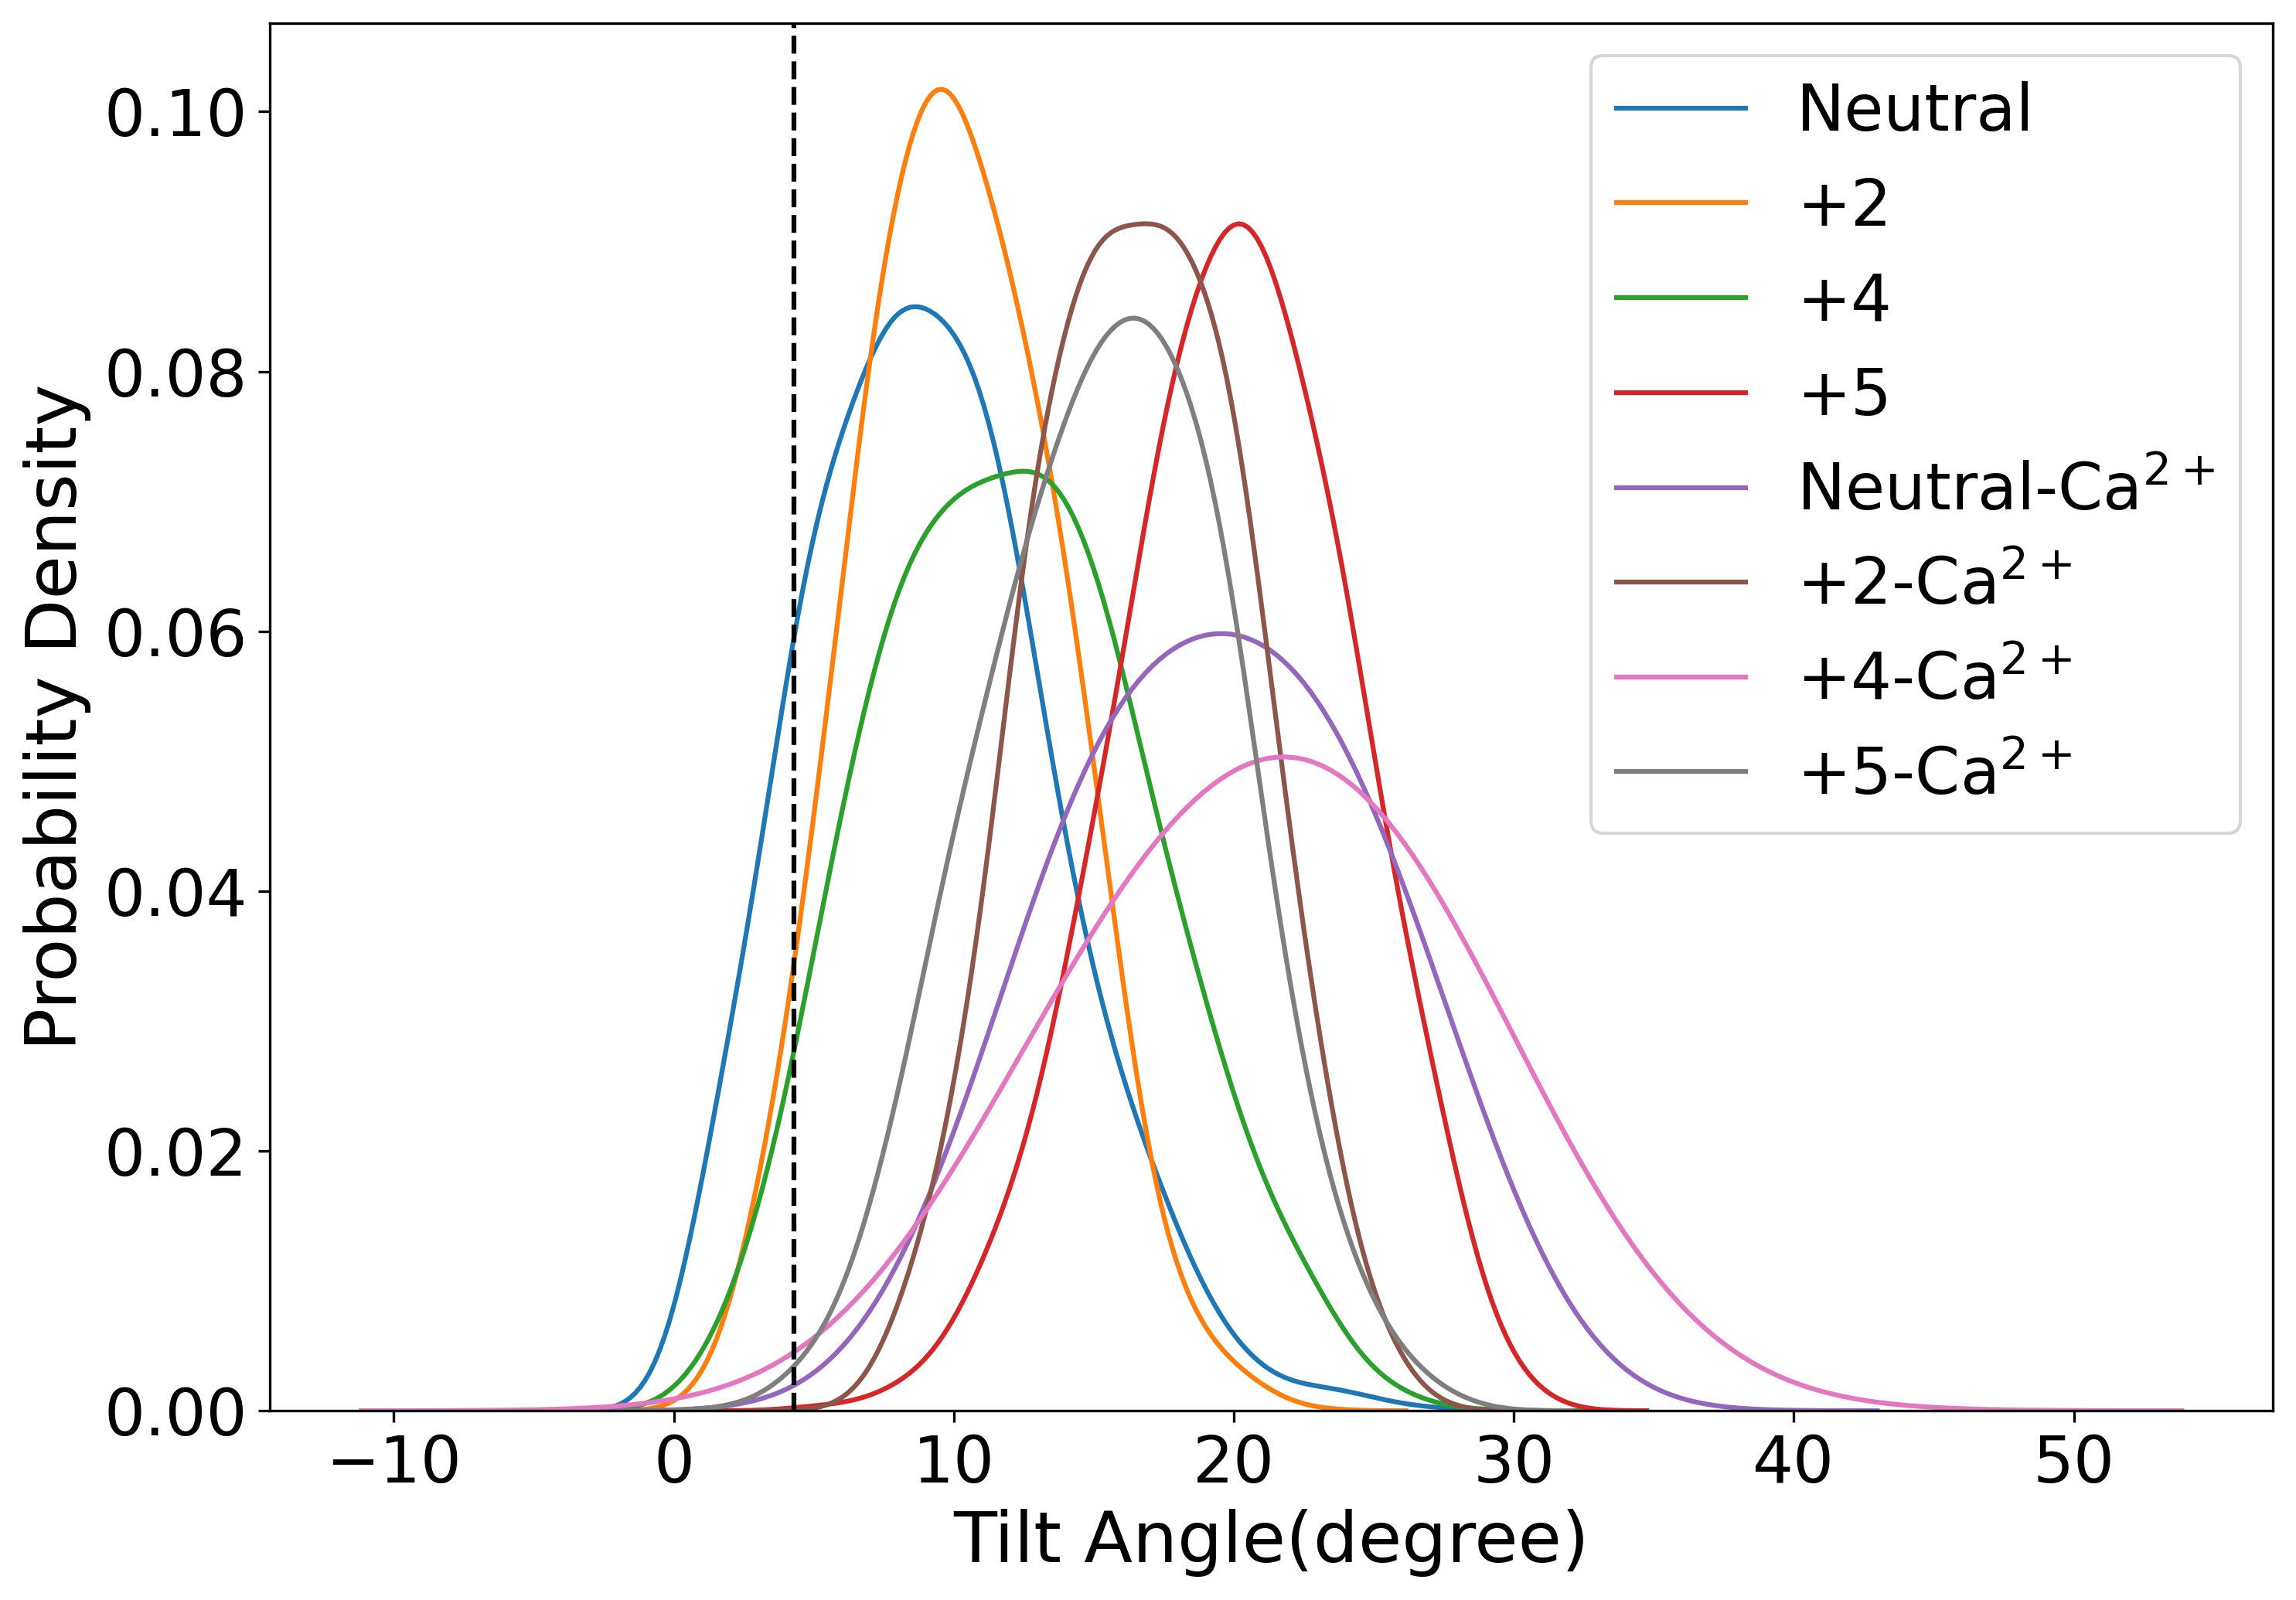

In [47]:
plt.figure(figsize=[10,7],dpi=300)
sns.kdeplot(neutral,label = "Neutral",bw_adjust=1.5)
sns.kdeplot(two,label = "+2",bw_adjust=1.5)
sns.kdeplot(four,label = "+4",bw_adjust=1.5)
sns.kdeplot(five,label = "+5",bw_adjust=1.5)
sns.kdeplot(neutral_ca,label = r"Neutral-Ca$^{2+}$",bw_adjust=3)
sns.kdeplot(two_ca,label = r"+2-Ca$^{2+}$",bw_adjust=1.5)
sns.kdeplot(four_ca,label = r"+4-Ca$^{2+}$",bw_adjust=5)
sns.kdeplot(five_ca,label = r"+5-Ca$^{2+}$",bw_adjust=1.5)
plt.axvline(x = 4.3, color="black",linestyle="--")

plt.xlabel("Tilt Angle(degree)",fontsize=22)
plt.xticks(fontsize=20)
plt.ylabel("Probability Density", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.legend(fontsize=20)
#plt.savefig("Tilt_five.pdf",dpi=300)
plt.savefig("Tilt_angle_probability.png",dpi=300)
plt.show()

In [114]:
print(np.mean(four))

12.1166394738


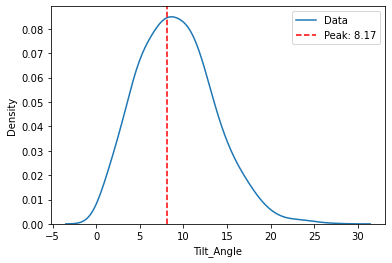

In [118]:
import scipy.stats as stats

data = np.random.normal(loc=0, scale=1, size=1000)

g = df_two

sns.kdeplot(g, label="Data",bw_adjust=1.5)

kde = stats.gaussian_kde(g)

x_values = np.linspace(min(g), max(g), 1000)
peak_x = x_values[np.argmax(kde(x_values))]

plt.axvline(x=peak_x, color='r', linestyle='--', label=f'Peak: {peak_x:.2f}')

plt.legend()
plt.show()

In [1]:
g = two

ax = sns.kdeplot(g)
x = ax.lines[0].get_xdata()
y = ax.lines[0].get_ydata()
maxid = np.argmax(y) 
plt.plot(x[maxid],y[maxid], 'bo', ms=10)
plt.axvline(x=x[maxid], color='r', linestyle='--', label=f'Peak: {x[maxid]:.2f}')
plt.legend()

NameError: name 'two' is not defined

In [7]:
print(np.max(df_two['Tilt_Angle']))

23.202


In [12]:
water_neutral = pd.read_csv("../water_molecules/df_neutral.csv")
water_neutral_ca = pd.read_csv("../water_molecules/df_neutal_ca.csv")

water_two = pd.read_csv("../water_molecules/df_two.csv")
water_two_ca = pd.read_csv("../water_molecules/df_two_ca.csv")

water_four = pd.read_csv("../water_molecules/df_four.csv")
water_four_ca = pd.read_csv("../water_molecules/df_four_ca.csv")

water_five = pd.read_csv("../water_molecules/df_five.csv")
water_five_ca = pd.read_csv("../water_molecules/df_five_ca.csv")

In [16]:
print(df_neutral)

            Tilt_Angle
Timeframes            
0              5.93670
1              7.14622
2             10.63990
3              9.89481
4              7.68587
...                ...
4996           3.56057
4997           2.93498
4998           1.82070
4999           5.18637
5000           4.30584

[5001 rows x 1 columns]


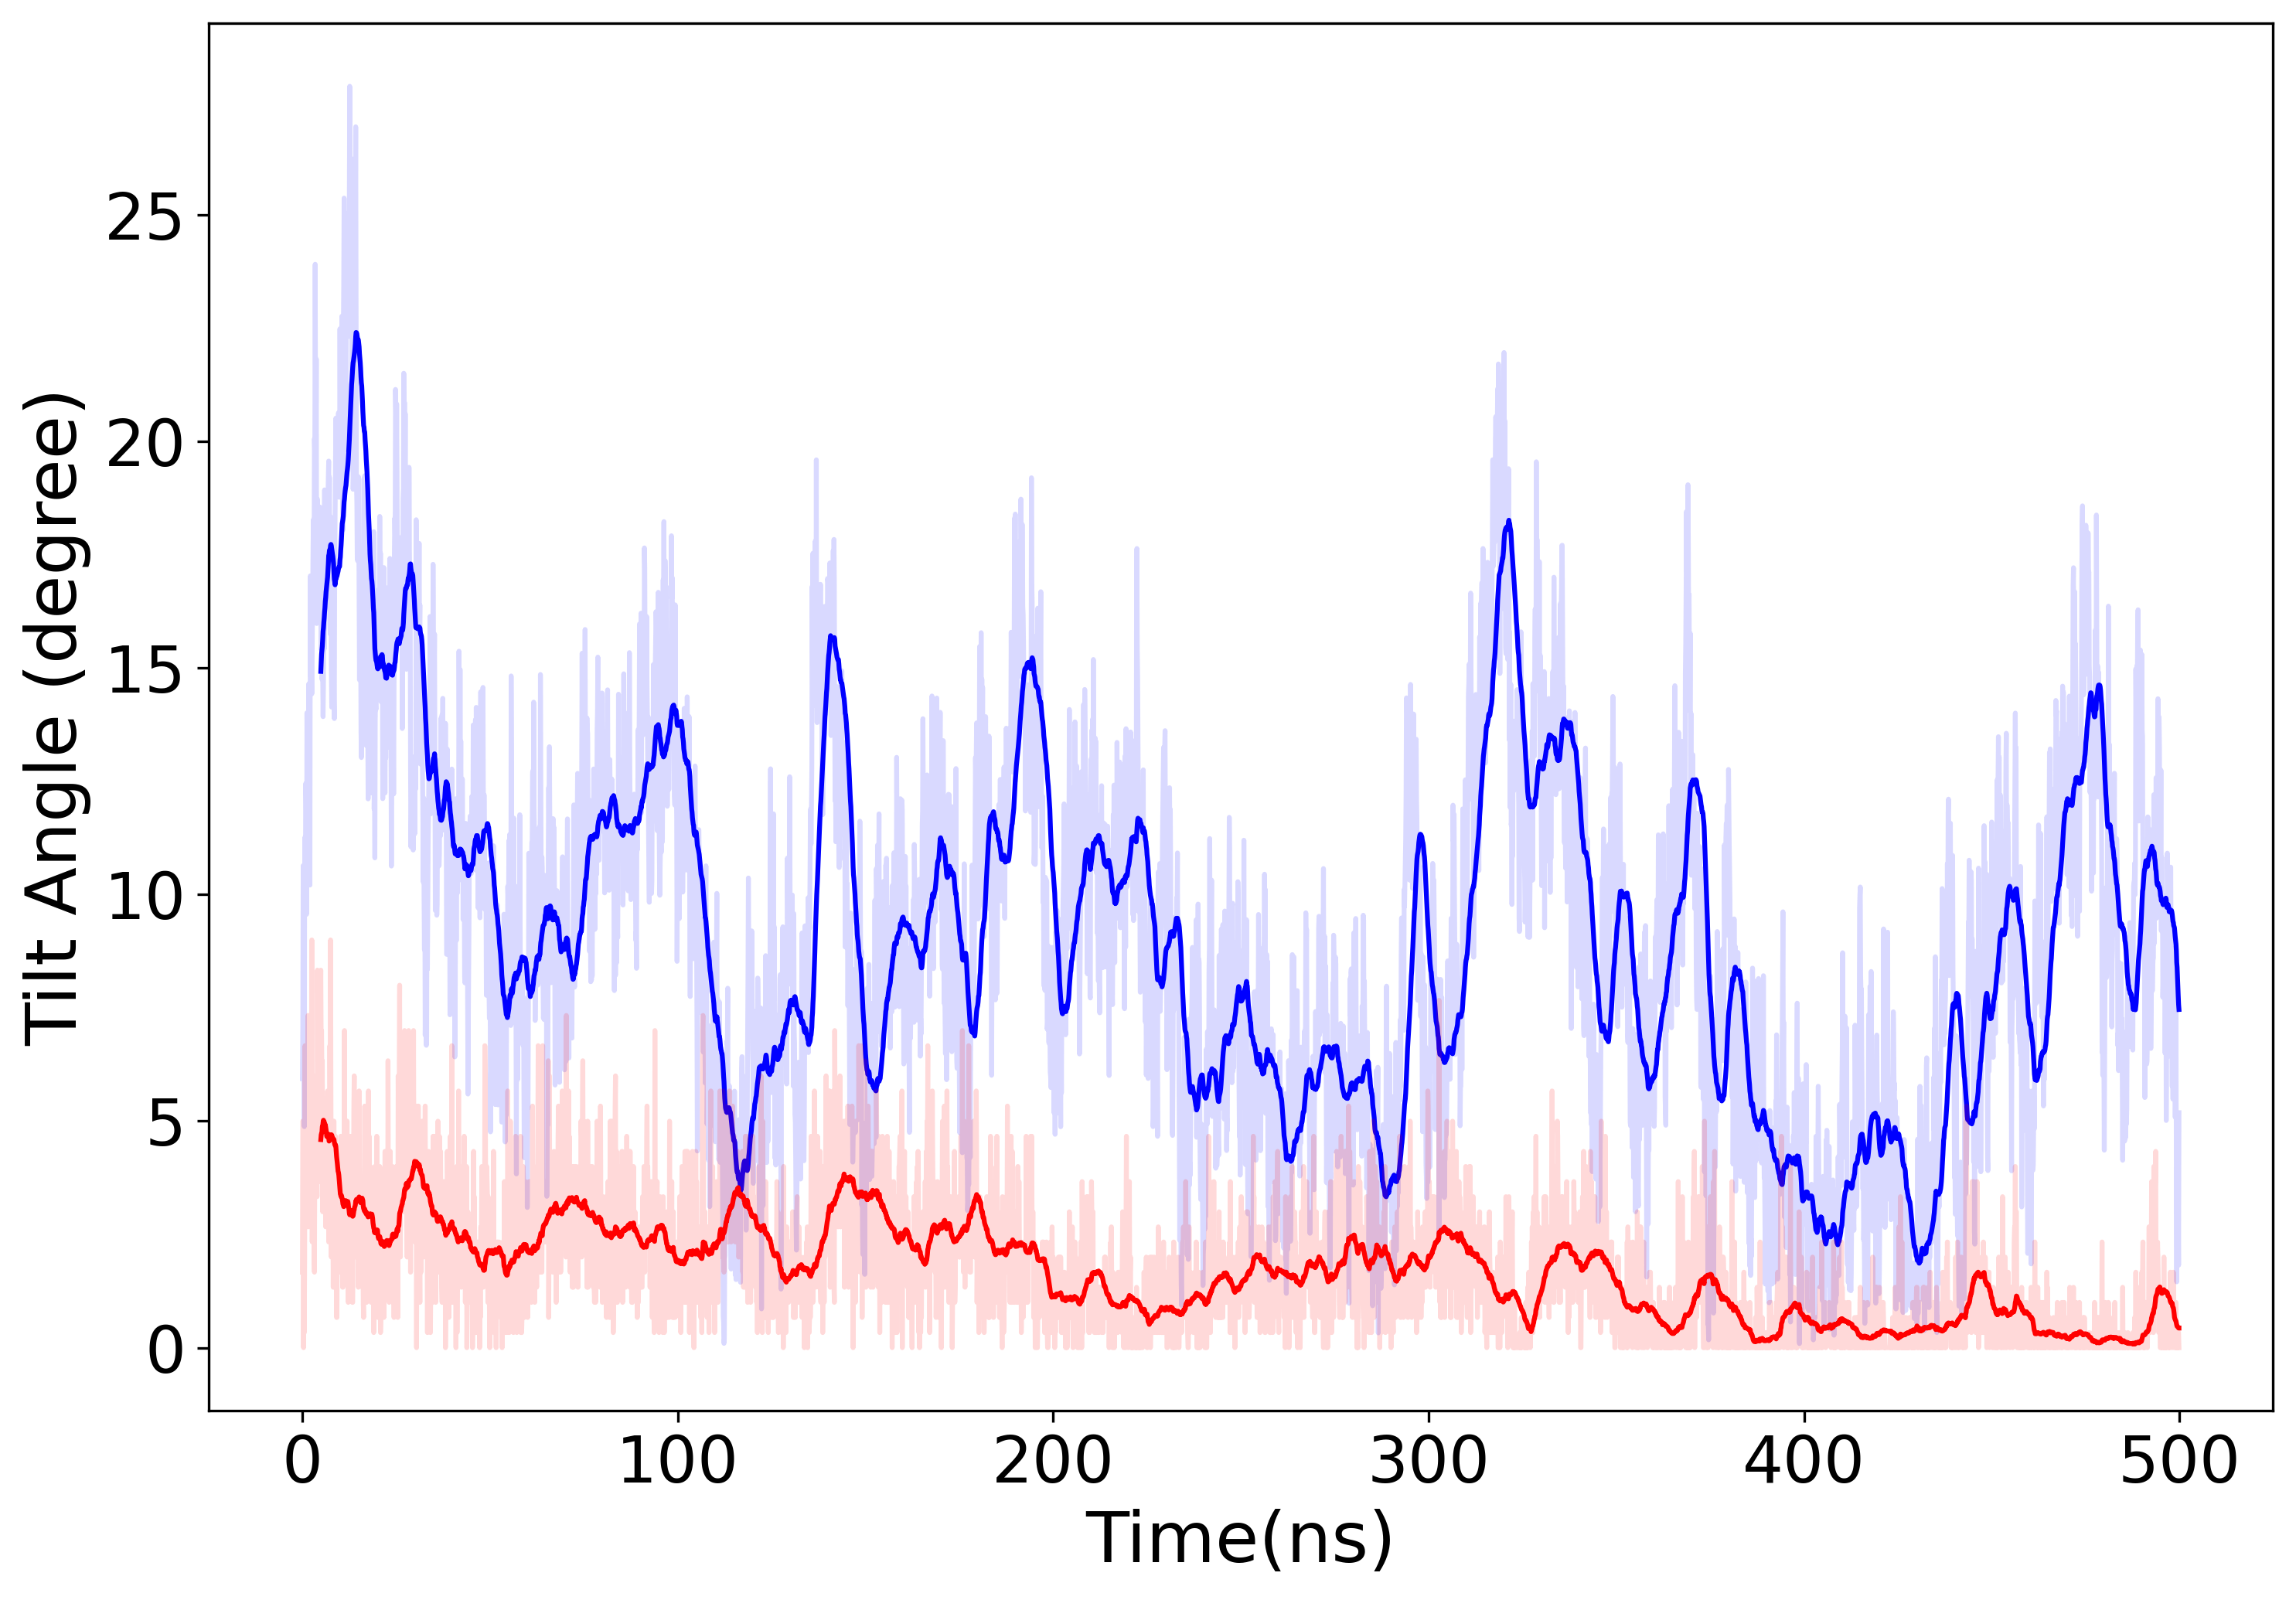

In [27]:
fig,ax = plt.subplots(figsize = (10,7),dpi=300
plt.plot(df_neutral.index[:5000]/10,df_neutral['Tilt_Angle'][:5000],color="blue",alpha=0.15)
#plt.plot(df_neutral['Timeframes'][:5000]/10,df_neutral['Tilt_Angle'][:5000],color="blue",alpha=0.15)
rolling_avg = df_neutral['Tilt_Angle'][:5000].rolling(window=50).mean()
plt.plot(df_neutral.index[:5000]/10,rolling_avg,color="blue",label = "Tilt angle")

plt.plot(water_neutral['Timeframe'][:5000],water_neutral['Water molecules'][:5000],color="red",alpha=0.15)
rolling_water = water_neutral['Water molecules'][:5000].rolling(window=50).mean()
plt.plot(water_neutral['Timeframe'][:5000],rolling_water,color="red",label= "Number of water molecules")

'''
plt.plot(df_five_ca['Timeframes'][:5000]/10,df_five_ca['Tilt_Angle'][:5000],color="red",alpha=0.15)
rolling_avg = df_five_ca['Tilt_Angle'][:5000].rolling(window=50).mean()
plt.plot(df_five['Timeframes'][:5000]/10,rolling_avg,color="red",label = r"with Ca$^{2+}$")
'''
ax.set_xlabel("Time(ns)",fontsize=22)
plt.xticks(fontsize=20)
ax.set_ylabel("Tilt Angle (degree)", fontsize=22)
plt.yticks(fontsize=20)
plt.tight_layout()
#plt.legend(fontsize=20)
#plt.savefig("Tilt_five.png",dpi=300)
#plt.savefig("Number of water molecules with and without Ca (rolling).png",dpi=300)
plt.show()

In [43]:
def plot_tilt_water(df1, df2, save_name):
    fig = plt.figure(figsize=[10, 7], dpi=300)
    gs = fig.add_gridspec(2, hspace=0)
    axs = gs.subplots(sharex=True)

    axs[0].plot(df1.index[:5000] / 10, df1['Tilt_Angle'][:5000], color="blue", alpha=0.15)
    rolling_avg_df1 = df1['Tilt_Angle'].rolling(window=50).mean()
    axs[0].plot(df1.index[:5000] / 10, rolling_avg_df1[:5000], color="blue", label="Tilt angle")

    axs[1].plot(df2['Timeframe'][:5000], df2['Water molecules'][:5000], color="orange", alpha=0.15)
    rolling_avg_df2 = df2['Water molecules'].rolling(window=50).mean()
    axs[1].plot(df2['Timeframe'][:5000], rolling_avg_df2[:5000], color="orange", label="No. of water molecules")

    axs[0].set_xlabel("Time (ns)", fontsize=22)
    axs[0].tick_params(axis='x', labelsize=20)
    axs[0].set_ylabel("Tilt angle($\degree$)", fontsize=22)
    axs[0].tick_params(axis='y', labelsize=20)
    axs[1].set_xlabel("Time (ns)", fontsize=22)
    axs[1].tick_params(axis='x', labelsize=20)
    axs[1].set_ylabel("No. of Water Molecules", fontsize=22)
    axs[1].tick_params(axis='y', labelsize=20)
    plt.tight_layout()
    #plt.axvline(x = 100 , color="black",linestyle="--")
    plt.savefig(save_name, dpi=300)
    plt.show()

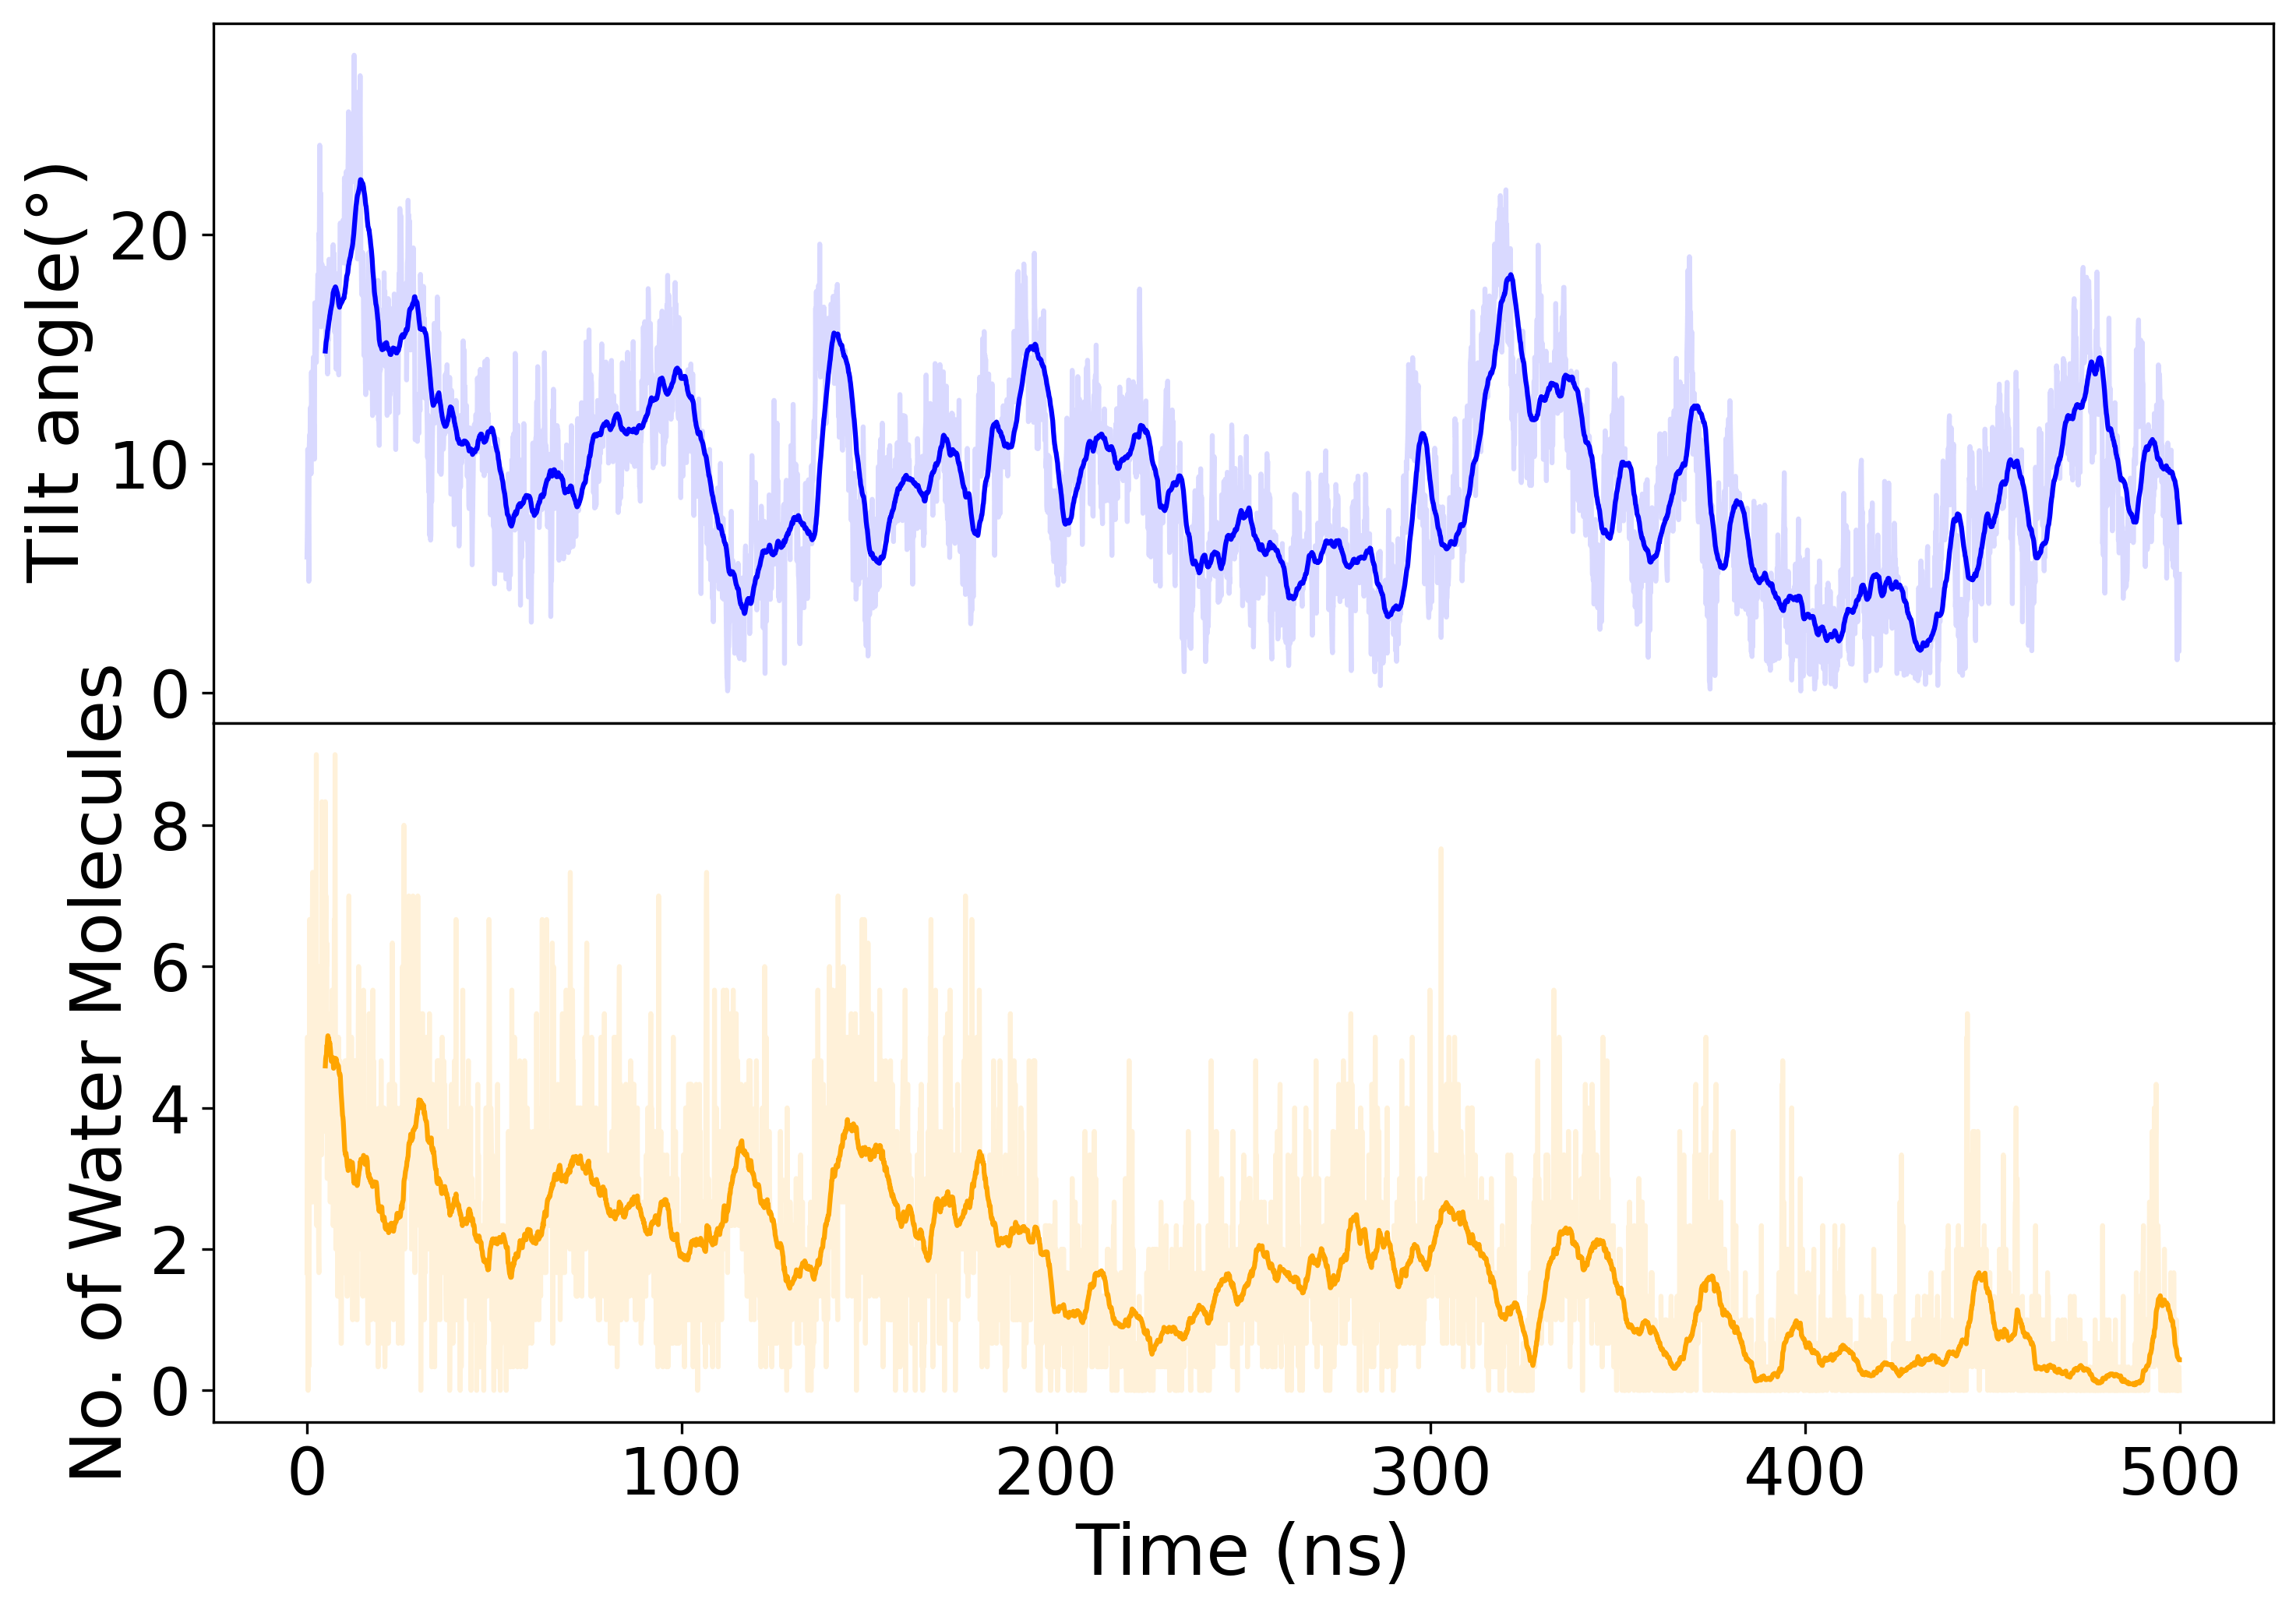

In [44]:
plot_tilt_water(df_neutral,water_neutral,"tilt_water.png")